# Importing Libraries and Git.

In [14]:

#!git clone https://github.com/marco-siino/EEG-ATCNet.git
%pip install mne
%pip install PyWavelets

import os
import sys
import shutil
import time
import pywt
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.metrics import cohen_kappa_score
from sklearn.model_selection import train_test_split
os.chdir("/home/giuseppe_bonomo/DATASET/BCI2a_IV")

import models_original as models
from preprocess import get_data
# from keras.utils.vis_utils import plot_model

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Organize the dataset.

In [15]:
# Creare la cartella "dataset" e "results" se non esistono già
os.makedirs("dataset", exist_ok=True)

# Creare le cartelle da s1 a s9
for i in range(1, 10):
    os.makedirs(f"dataset/s{i}", exist_ok=True)

In [16]:
"""# Download the dataset.
base_url = "https://bnci-horizon-2020.eu/database/data-sets/001-2014/"
save_path = "dataset/"

for i in range(1, 10):  # Da A01 a A09
    for suffix in ["T", "E"]:  # T per training, E per evaluation
        filename = f"A{i:02d}{suffix}.mat"
        url = base_url + filename
        os.system(f"wget -O {save_path}s{i}/{filename} {url}")"""

'# Download the dataset.\nbase_url = "https://bnci-horizon-2020.eu/database/data-sets/001-2014/"\nsave_path = "dataset/"\n\nfor i in range(1, 10):  # Da A01 a A09\n    for suffix in ["T", "E"]:  # T per training, E per evaluation\n        filename = f"A{i:02d}{suffix}.mat"\n        url = base_url + filename\n        os.system(f"wget -O {save_path}s{i}/{filename} {url}")'

# Functions definitions

In [17]:
#%%
def draw_learning_curves(history, sub):
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy - subject: ' + str(sub))
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'val'], loc='upper left')
    plt.show()
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss - subject: ' + str(sub))
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'val'], loc='upper left')
    plt.show()
    plt.close()

def draw_confusion_matrix(cf_matrix, sub, results_path, classes_labels):
    # Generate confusion matrix plot
    display_labels = classes_labels
    disp = ConfusionMatrixDisplay(confusion_matrix=cf_matrix,
                                display_labels=display_labels)
    disp.plot()
    disp.ax_.set_xticklabels(display_labels, rotation=12)
    plt.title('Confusion Matrix of Subject: ' + sub )
    plt.savefig(results_path + '/subject_' + sub + '.png')
    plt.show()

def draw_performance_barChart(num_sub, metric, label):
    fig, ax = plt.subplots()
    x = list(range(1, num_sub+1))
    ax.bar(x, metric, 0.5, label=label)
    ax.set_ylabel(label)
    ax.set_xlabel("Subject")
    ax.set_xticks(x)
    ax.set_title('Model '+ label + ' per subject')
    ax.set_ylim([0,1])

## Preprocessing functions

## DB4 (Soft -> Threshold 5.5)

In [18]:
def db4_soft(signal, wavelet='db4', level=4, threshold=5.5):
    """
    Applica la RDWT (Discrete Wavelet Transform) al segnale e lo ricostruisce,
    rimuovendo i coefficienti di dettaglio sotto una certa soglia per enfatizzare
    le caratteristiche principali del segnale.

    Args:
    - signal: il segnale da elaborare
    - wavelet: tipo di wavelet da utilizzare (default 'db4')
    - level: livello della decomposizione (default 4)
    - threshold: soglia per i coefficienti di dettaglio (default 0.5)

    Returns:
    - Il segnale ricostruito dopo la manipolazione della RDWT
    """


    print("Lunghezza originale:", signal.shape[-1])  # Dovrebbe essere 1125
    coeffs = pywt.wavedec(signal, wavelet, mode='per', level=level)
    print("Lunghezza coefficiente di approssimazione:", len(coeffs[0]))

    reconstructed_signal = pywt.waverec(coeffs, wavelet, mode='per')
    print("Lunghezza ricostruita:", len(reconstructed_signal))

    # Decomposizione del segnale in coefficienti
    coeffs = pywt.wavedec(signal, wavelet, mode='per', level=level)

    # Modifica i coefficienti di dettaglio
    # Si applica un threshold sui coefficienti di dettaglio per "ridurre" la componente di alta frequenza
    coeffs_thresholded = [coeffs[0]]  # Mantieni il coefficiente di approssimazione
    for i in range(1, len(coeffs)):
        coeffs_thresholded.append(np.where(np.abs(coeffs[i]) < threshold, 0, coeffs[i]))

    # Ricostruzione del segnale dai coefficienti modificati
    reconstructed_signal = pywt.waverec(coeffs_thresholded, wavelet, mode='per')

    # Taglia il segnale ricostruito per mantenerne la stessa lunghezza dell'input
    return reconstructed_signal[:len(signal)]


## DB4 (Hard -> Threshold 10.5)

In [19]:
def db4_hard(signal, wavelet='db4', level=4, threshold=10.5):
    """
    Applica la RDWT (Discrete Wavelet Transform) al segnale e lo ricostruisce,
    rimuovendo i coefficienti di dettaglio sotto una certa soglia per enfatizzare
    le caratteristiche principali del segnale.

    Args:
    - signal: il segnale da elaborare
    - wavelet: tipo di wavelet da utilizzare (default 'db4')
    - level: livello della decomposizione (default 4)
    - threshold: soglia per i coefficienti di dettaglio (default 0.5)

    Returns:
    - Il segnale ricostruito dopo la manipolazione della RDWT
    """

    # Decomposizione del segnale in coefficienti
    coeffs = pywt.wavedec(signal, wavelet, mode='per', level=level)

    # Modifica i coefficienti di dettaglio
    # Si applica un threshold sui coefficienti di dettaglio per "ridurre" la componente di alta frequenza
    coeffs_thresholded = [coeffs[0]]  # Mantieni il coefficiente di approssimazione
    for i in range(1, len(coeffs)):
        coeffs_thresholded.append(np.where(np.abs(coeffs[i]) < threshold, 0, coeffs[i]))

    # Ricostruzione del segnale dai coefficienti modificati
    reconstructed_signal = pywt.waverec(coeffs_thresholded, wavelet, mode='per')

    # Taglia il segnale ricostruito per mantenerne la stessa lunghezza dell'input
    return reconstructed_signal[:len(signal)]


## RDWT

In [20]:
import numpy as np
import scipy.signal as signal
import pywt

def rational_dilated_wavelet_transform(sig, wavelet='db4', levels=4, dilation_factors=None, threshold=5.5):
    """
    Applica la Rational Dilated Wavelet Transform (RDWT) a un segnale EEG multidimensionale.

    Args:
    - sig: array numpy di forma (eventi, 1, canali, campioni)
    - wavelet: tipo di wavelet da utilizzare (default 'db4')
    - levels: numero di livelli di decomposizione (default 4)
    - dilation_factors: lista di fattori di dilatazione razionale (default: [3/2, 5/3, 7/4, ...])
    - threshold: soglia per i coefficienti di dettaglio (default 5.5)

    Returns:
    - Segnale ricostruito con la RDWT (stessa dimensione dell'input)
    """
    eventi, _, canali, campioni = sig.shape
    print("Lunghezza originale del segnale:", sig.shape)

    if dilation_factors is None:
        dilation_factors = [3/2, 5/3, 7/4, 9/5]

    coeffs_approx = sig.copy()  # Inizializza con il segnale originale
    detail_coeffs = []

    for i in range(levels):
        factor = dilation_factors[i]
        wavelet_filter = pywt.Wavelet(wavelet)
        lo_d, hi_d = wavelet_filter.dec_lo, wavelet_filter.dec_hi

        # Ridimensionamento dei filtri
        lo_d = signal.resample(lo_d, int(len(lo_d) * factor))
        hi_d = signal.resample(hi_d, int(len(hi_d) * factor))

        print(f"Livello {i+1}: coeffs_approx shape {coeffs_approx.shape}, lo_d shape {lo_d.shape}, hi_d shape {hi_d.shape}")

        approx = np.zeros_like(coeffs_approx)
        detail = np.zeros_like(coeffs_approx)

        # Applica la convoluzione per ogni canale EEG
        for e in range(eventi):
            for c in range(canali):
                approx[e, 0, c, :] = np.convolve(coeffs_approx[e, 0, c, :], lo_d, mode='same')
                detail[e, 0, c, :] = np.convolve(coeffs_approx[e, 0, c, :], hi_d, mode='same')

                # Soglia sui coefficienti di dettaglio
                detail[e, 0, c, np.abs(detail[e, 0, c, :]) < threshold] = 0

        detail_coeffs.append(detail)
        coeffs_approx = approx  # Passa l'approssimazione al livello successivo

    # Ricostruzione del segnale
    reconstructed = coeffs_approx.copy()
    for i in range(levels-1, -1, -1):
        reconstructed += detail_coeffs[i]

    print("Lunghezza del segnale ricostruito:", reconstructed.shape)
    return reconstructed

In [21]:
def apply_preprocessing (signals_data, preprocessing):
  if preprocessing=="none":
    return signals_data
  elif preprocessing=="db4_soft":
    return db4_soft(signals_data)
  elif preprocessing=="db4_hard":
    return db4_hard(signals_data)
  elif preprocessing=="rdwt":
    return rational_dilated_wavelet_transform(signals_data)


# Model training function

In [22]:
#%% Training
def train(dataset_conf, train_conf, results_path):

    # remove the 'result' folder before training
    if os.path.exists(results_path):
        # Remove the folder and its contents
        shutil.rmtree(results_path)
        os.makedirs(results_path)

    # Get the current 'IN' time to calculate the overall training time
    in_exp = time.time()
    # Create a file to store the path of the best model among several runs
    best_models = open(results_path + "/best models ATCNet.txt", "w")
    # Create a file to store performance during training
    log_write = open(results_path + "/log ATCNet.txt", "w")

    # Get dataset parameters
    dataset = dataset_conf.get('name')
    n_sub = dataset_conf.get('n_sub')
    data_path = dataset_conf.get('data_path')
    isStandard = dataset_conf.get('isStandard')
    LOSO = dataset_conf.get('LOSO')
    # Get training hyperparamters
    batch_size = train_conf.get('batch_size')
    epochs = train_conf.get('epochs')
    signal_preprocessing = dataset_conf.get('signal_preprocessing')
    patience = train_conf.get('patience')
    lr = train_conf.get('lr')
    LearnCurves = train_conf.get('LearnCurves') # Plot Learning Curves?
    n_train = train_conf.get('n_train')
    model_name = train_conf.get('model')
    from_logits = train_conf.get('from_logits')

    # Initialize variables
    acc = np.zeros((n_sub, n_train))
    kappa = np.zeros((n_sub, n_train))

    # Iteration over subjects
    # for sub in range(n_sub-1, n_sub): # (num_sub): for all subjects, (i-1,i): for the ith subject.
    for sub in range(n_sub): # (num_sub): for all subjects, (i-1,i): for the ith subject.

        print('\nTraining on subject ', sub+1)
        log_write.write( '\nTraining on subject '+ str(sub+1) +'\n')
        # Initiating variables to save the best subject accuracy among multiple runs.
        BestSubjAcc = 0
        bestTrainingHistory = []

        # Get training and validation data
        X_train, _, y_train_onehot, _, _, _ = get_data(
            data_path, sub, dataset, LOSO = LOSO, isStandard = isStandard)

        # Divide the training data into training and validation
        X_train, X_val, y_train_onehot, y_val_onehot = train_test_split(X_train, y_train_onehot, test_size=0.2, random_state=42)


        print("\n\nBefore preprocessing X_train shape is:"+str(X_train.shape))
        print("Before preprocessing X_val shape is:"+str(X_val.shape))
        
        X_train = apply_preprocessing(X_train, preprocessing=signal_preprocessing)
        X_val = apply_preprocessing(X_val, preprocessing=signal_preprocessing)
        
        print("\n\nAfter preprocessing X_train shape is:"+str(X_train.shape))
        print("After preprocessing X_val shape is:"+str(X_val.shape))
        
        # --- INIZIO MODIFICA: Correzione per shape mismatch ---
        # L'errore indica che il modello si aspetta 1125 campioni, ma i dati ne hanno 1126.
        # Trimmiano l'ultimo campione per farli corrispondere.
        
        expected_shape = 1125 # Dimensione attesa dal modello
        
        if X_train.shape[-1] != expected_shape:
            print(f"WARNING: Trimming X_train last dimension from {X_train.shape[-1]} to {expected_shape}")
            X_train = X_train[..., :expected_shape]
            
        if X_val.shape[-1] != expected_shape:
            print(f"WARNING: Trimming X_val last dimension from {X_val.shape[-1]} to {expected_shape}")
            X_val = X_val[..., :expected_shape]
            
        print(f"New X_train shape is: {X_train.shape}")
        print(f"New X_val shape is: {X_val.shape}")
        # --- FINE MODIFICA ---


        # Iteration over multiple runs
        for train in range(n_train): # How many repetitions of training for subject i.
            # Set the random seed for TensorFlow and NumPy random number generator.
            # The purpose of setting a seed is to ensure reproducibility in random operations.
            tf.random.set_seed(train+1)
            np.random.seed(train+1)

            # Get the current 'IN' time to calculate the 'run' training time
            in_run = time.time()

            # Create folders and files to save trained models for all runs
            filepath = results_path + '/saved models/run-{}'.format(train+1)
            if not os.path.exists(filepath):
                os.makedirs(filepath)
            filepath = filepath + '/subject-{}.weights.h5'.format(sub+1)

            # Create the model
            model = getModel(model_name, dataset_conf, from_logits)
            # Compile and train the model
            model.compile(loss=CategoricalCrossentropy(from_logits=from_logits), optimizer=AdamW(learning_rate=lr), metrics=['accuracy'])

            # model.summary()
            # plot_model(model, to_file='plot_model.png', show_shapes=True, show_layer_names=True)

            callbacks = [
                ModelCheckpoint(filepath, monitor='val_loss', verbose=0,
                                save_best_only=True, save_weights_only=True, mode='min'),
                ReduceLROnPlateau(monitor="val_loss", factor=0.90, patience=20, verbose=0, min_lr=0.0001),
                # EarlyStopping(monitor='val_loss', verbose=1, mode='min', patience=patience)
            ]
            history = model.fit(X_train, y_train_onehot, validation_data=(X_val, y_val_onehot),
                                epochs=epochs, batch_size=batch_size, callbacks=callbacks, verbose=0)

            # Evaluate the performance of the trained model based on the validation data
            # Here we load the Trained weights from the file saved in the hard
            # disk, which should be the same as the weights of the current model.
            model.load_weights(filepath)
            y_pred = model.predict(X_val)

            if from_logits:
                y_pred = tf.nn.softmax(y_pred).numpy().argmax(axis=-1)
            else:
                y_pred = y_pred.argmax(axis=-1)

            labels = y_val_onehot.argmax(axis=-1)
            acc[sub, train]  = accuracy_score(labels, y_pred)
            kappa[sub, train] = cohen_kappa_score(labels, y_pred)

            # Get the current 'OUT' time to calculate the 'run' training time
            out_run = time.time()
            # Print & write performance measures for each run
            info = 'Subject: {}   seed {}   time: {:.1f} m   '.format(sub+1, train+1, ((out_run-in_run)/60))
            info = info + 'valid_acc: {:.4f}   valid_loss: {:.3f}'.format(acc[sub, train], min(history.history['val_loss']))
            print(info)
            log_write.write(info +'\n')
            # If current training run is better than previous runs, save the history.
            if(BestSubjAcc < acc[sub, train]):
                 BestSubjAcc = acc[sub, train]
                 bestTrainingHistory = history

        # Store the path of the best model among several runs
        best_run = np.argmax(acc[sub,:])
        filepath = '/saved models/run-{}/subject-{}.h5'.format(best_run+1, sub+1)+'\n'
        best_models.write(filepath)

        # Plot Learning curves
        if (LearnCurves == True):
            print('Plot Learning Curves ....... ')
            draw_learning_curves(bestTrainingHistory, sub+1)

    # Get the current 'OUT' time to calculate the overall training time
    out_exp = time.time()

    # Print & write the validation performance using all seeds
    head1 = head2 = '         '
    for sub in range(n_sub):
        head1 = head1 + 'sub_{}   '.format(sub+1)
        head2 = head2 + '-----   '
    head1 = head1 + '  average'
    head2 = head2 + '  -------'
    info = '\n---------------------------------\nValidation performance (acc %):'
    info = info + '\n---------------------------------\n' + head1 +'\n'+ head2
    for run in range(n_train):
        info = info + '\nSeed {}:  '.format(run+1)
        for sub in range(n_sub):
            info = info + '{:.2f}   '.format(acc[sub, run]*100)
        info = info + '  {:.2f}   '.format(np.average(acc[:, run])*100)
    info = info + '\n---------------------------------\nAverage acc - all seeds: '
    info = info + '{:.2f} %\n\nTrain Time  - all seeds: {:.1f}'.format(np.average(acc)*100, (out_exp-in_exp)/(60))
    info = info + ' min\n---------------------------------\n'
    print(info)
    log_write.write(info+'\n')

    # Close open files
    best_models.close()
    log_write.close()


# Evaluation function

In [23]:
#%% Evaluation
def test(model, dataset_conf, results_path, allRuns = True):
    # Open the  "Log" file to write the evaluation results
    log_write = open(results_path + "/log ATCNet.txt", "a")

    # Get dataset paramters
    dataset = dataset_conf.get('name')
    signal_preprocessing = dataset_conf.get('signal_preprocessing')
    n_classes = dataset_conf.get('n_classes')
    n_sub = dataset_conf.get('n_sub')
    data_path = dataset_conf.get('data_path')
    isStandard = dataset_conf.get('isStandard')
    LOSO = dataset_conf.get('LOSO')
    classes_labels = dataset_conf.get('cl_labels')
    #Ripetuto
    #signal_preprocessing = dataset_conf.get('signal_preprocessing')

    # Test the performance based on several runs (seeds)
    runs = os.listdir(results_path+"/saved models")
    # Initialize variables
    acc = np.zeros((n_sub, len(runs)))
    kappa = np.zeros((n_sub, len(runs)))
    cf_matrix = np.zeros([n_sub, len(runs), n_classes, n_classes])

    # Iteration over subjects
    # for sub in range(n_sub-1, n_sub): # (num_sub): for all subjects, (i-1,i): for the ith subject.
    inference_time = 0 #  inference_time: classification time for one trial
    for sub in range(n_sub): # (num_sub): for all subjects, (i-1,i): for the ith subject.
        # Load data
        _, _, _, X_test, _, y_test_onehot = get_data(data_path, sub, dataset, LOSO = LOSO, isStandard = isStandard)

        X_test = apply_preprocessing(X_test, preprocessing=signal_preprocessing)

        # --- INIZIO MODIFICA: Correzione per shape mismatch su X_test ---
        # L'errore indica che il modello si aspetta 1125 campioni, ma i dati ne hanno 1126.
        # Trimmiano l'ultimo campione per farli corrispondere.
        
        expected_shape = 1125 # Dimensione attesa dal modello
        
        if X_test.shape[-1] != expected_shape:
            print(f"WARNING: Trimming X_test last dimension from {X_test.shape[-1]} to {expected_shape}")
            X_test = X_test[..., :expected_shape]
            
        print(f"New X_test shape is: {X_test.shape}")
        # --- FINE MODIFICA ---
        
        # Iteration over runs (seeds)
        for seed in range(len(runs)):
            # Load the model of the seed.
            model.load_weights('{}/saved models/{}/subject-{}.weights.h5'.format(results_path, runs[seed], sub+1))

            inference_time = time.time()
            # Predict MI task
            y_pred = model.predict(X_test).argmax(axis=-1)
            inference_time = (time.time() - inference_time)/X_test.shape[0]
            # Calculate accuracy and K-score
            labels = y_test_onehot.argmax(axis=-1)
            acc[sub, seed]  = accuracy_score(labels, y_pred)
            kappa[sub, seed] = cohen_kappa_score(labels, y_pred)
            # Calculate and draw confusion matrix
            cf_matrix[sub, seed, :, :] = confusion_matrix(labels, y_pred, normalize='true')
            # draw_confusion_matrix(cf_matrix[sub, seed, :, :], str(sub+1), results_path, classes_labels)

    # Print & write the average performance measures for all subjects
    head1 = head2 = '                  '
    for sub in range(n_sub):
        head1 = head1 + 'sub_{}   '.format(sub+1)
        head2 = head2 + '-----   '
    head1 = head1 + '  average'
    head2 = head2 + '  -------'
    info = '\n' + head1 +'\n'+ head2
    info = '\n---------------------------------\nTest performance (acc & k-score):\n'
    info = info + '---------------------------------\n' + head1 +'\n'+ head2
    for run in range(len(runs)):
        info = info + '\nSeed {}: '.format(run+1)
        info_acc = '(acc %)   '
        info_k = '        (k-sco)   '
        for sub in range(n_sub):
            info_acc = info_acc + '{:.2f}   '.format(acc[sub, run]*100)
            info_k = info_k + '{:.3f}   '.format(kappa[sub, run])
        info_acc = info_acc + '  {:.2f}   '.format(np.average(acc[:, run])*100)
        info_k = info_k + '  {:.3f}   '.format(np.average(kappa[:, run]))
        info = info + info_acc + '\n' + info_k
    info = info + '\n----------------------------------\nAverage - all seeds (acc %): '
    info = info + '{:.2f}\n                    (k-sco): '.format(np.average(acc)*100)
    info = info + '{:.3f}\n\nInference time: {:.2f}'.format(np.average(kappa), inference_time * 1000)
    info = info + ' ms per trial\n----------------------------------\n'
    print(info)
    log_write.write(info+'\n')

    # Draw a performance bar chart for all subjects
    draw_performance_barChart(n_sub, acc.mean(1), 'Accuracy')
    draw_performance_barChart(n_sub, kappa.mean(1), 'k-score')
    # Draw confusion matrix for all subjects (average)
    draw_confusion_matrix(cf_matrix.mean((0,1)), 'All', results_path, classes_labels)
    # Close opened file
    log_write.close()

# Model selection and setup

In [24]:
#%%
def getModel(model_name, dataset_conf, from_logits = False):

    n_classes = dataset_conf.get('n_classes')
    n_channels = dataset_conf.get('n_channels')
    in_samples = dataset_conf.get('in_samples')

    # Select the model
    if(model_name == 'RockNet'):
        # Train using the proposed ATCNet model: https://ieeexplore.ieee.org/document/9852687
        model = models.RockNet_(
            # Dataset parameters
            n_classes = n_classes,
            in_chans = n_channels,
            in_samples = in_samples,
            # Sliding window (SW) parameter
            n_windows = 5,
            # Attention (AT) block parameter
            attention = 'mha', # Options: None, 'mha','mhla', 'cbam', 'se'
            # Convolutional (CV) block parameters
            eegn_F1 = 16,
            eegn_D = 2,
            eegn_kernelSize = 64,
            eegn_poolSize = 7,
            eegn_dropout = 0.5,
            # Temporal convolutional (TC) block parameters
            tcn_depth = 2,
            tcn_kernelSize = 4,
            tcn_filters = 64,
            tcn_dropout = 0.3,
            tcn_activation='elu',
            )
    elif(model_name == 'RockNetA'):
        model = models.RockNetA(
            n_classes = n_classes,
            in_chans = n_channels,
            in_samples = in_samples,
            n_windows = 5,
            attention = 'mha',
            eegn_F1 = 16,
            eegn_D = 2,
            eegn_kernelSize = 64,
            eegn_poolSize = 7,
            eegn_dropout = 0.5,
            tcn_depth = 2,
            tcn_kernelSize = 4,
            tcn_filters = 32,
            tcn_dropout = 0.3,
            tcn_activation='elu',
        )
    elif(model_name == 'RockNetB'):
        model = models.RockNetB(
            n_classes = n_classes,
            in_chans = n_channels,
            in_samples = in_samples,
            n_windows = 5,
            attention = 'mha',
            eegn_F1 = 16,
            eegn_D = 2,
            eegn_kernelSize = 64,
            eegn_poolSize = 7,
            eegn_dropout = 0.5,
            tcn_depth = 2,
            tcn_kernelSize = 4,
            tcn_filters = 32,
            tcn_dropout = 0.3,
            tcn_activation='elu',
        )
    elif(model_name == 'RockNetC'):
        model = models.RockNetC(
            n_classes = n_classes,
            in_chans = n_channels,
            in_samples = in_samples,
            n_windows = 5,
            attention = 'mha',
            eegn_F1 = 16,
            eegn_D = 2,
            eegn_kernelSize = 64,
            eegn_poolSize = 7,
            eegn_dropout = 0.5,
            tcn_depth = 2,
            tcn_kernelSize = 4,
            tcn_filters = 32,
            tcn_dropout = 0.3,
            tcn_activation='elu',
        )
    elif(model_name == 'RockNetX'):
        model = models.RockNetX(
            n_classes = n_classes,
            in_chans = n_channels,
            in_samples = in_samples,
            n_windows = 5,
            attention = 'transformer',
            eegn_F1 = 16,
            eegn_D = 2,
            eegn_kernelSize = 64,
            eegn_poolSize = 7,
            eegn_dropout = 0.5,
            tcn_depth = 3,
            tcn_kernelSize = 4,
            tcn_filters = 64,
            tcn_dropout = 0.3,
            tcn_activation='gelu',
        )
    elif(model_name == 'RockNetY'):
        model = models.RockNetY(
            n_classes = n_classes,
            in_chans = n_channels,
            in_samples = in_samples,
            n_windows = 5,
            attention = 'mha',
            eegn_F1 = 16,
            eegn_D = 2,
            eegn_kernelSize = 64,
            eegn_poolSize = 7,
            eegn_dropout = 0.5,
            tcn_depth = 2,
            tcn_kernelSize = 4,
            tcn_filters = 32,
            tcn_dropout = 0.3,
            tcn_activation='elu',
        )
    elif(model_name == 'RockNetZ'):
        model = models.RockNetZ(
            n_classes = n_classes,
            in_chans = n_channels,
            in_samples = in_samples,
            n_windows = 5,
            attention = 'mha',
            eegn_F1 = 16,
            eegn_D = 2,
            eegn_kernelSize = 64,
            eegn_poolSize = 7,
            eegn_dropout = 0.5,
            tcn_depth = 2,
            tcn_kernelSize = 4,
            tcn_filters = 32,
            tcn_dropout = 0.3,
            tcn_activation='relu',
        )
    elif(model_name == 'ATCNet'):
        # Train using the proposed ATCNet model: https://ieeexplore.ieee.org/document/9852687
        model = models.ATCNet_(
             # Dataset parameters
            n_classes = n_classes, 
            in_chans = n_channels, 
            in_samples = in_samples, 
            # Sliding window (SW) parameter
            n_windows = 5, 
            # Attention (AT) block parameter
            attention = 'mha', # Options: None, 'mha','mhla', 'cbam', 'se'
            # Convolutional (CV) block parameters
            eegn_F1 = 16,
            eegn_D = 2, 
            eegn_kernelSize = 64,
            eegn_poolSize = 7,
            eegn_dropout = 0.3,
            # Temporal convolutional (TC) block parameters
            tcn_depth = 2, 
            tcn_kernelSize = 4,
            tcn_filters = 32,
            tcn_dropout = 0.3, 
            tcn_activation='elu',
            )
    elif(model_name == 'TCNet_Fusion'):
        # Train using TCNet_Fusion: https://doi.org/10.1016/j.bspc.2021.102826
        model = models.TCNet_Fusion(n_classes = n_classes, Chans=n_channels, Samples=in_samples)
    elif(model_name == 'EEGTCNet'):
        # Train using EEGTCNet: https://arxiv.org/abs/2006.00622
        model = models.EEGTCNet(n_classes = n_classes, Chans=n_channels, Samples=in_samples)
    elif(model_name == 'EEGNet'):
        # Train using EEGNet: https://arxiv.org/abs/1611.08024
        model = models.EEGNet_classifier(n_classes = n_classes, Chans=n_channels, Samples=in_samples)
    elif(model_name == 'EEGNeX'):
        # Train using EEGNeX: https://arxiv.org/abs/2207.12369
        model = models.EEGNeX_8_32(n_timesteps = in_samples , n_features = n_channels, n_outputs = n_classes)
    elif(model_name == 'DeepConvNet'):
        # Train using DeepConvNet: https://doi.org/10.1002/hbm.23730
        model = models.DeepConvNet(nb_classes = n_classes , Chans = n_channels, Samples = in_samples)
    elif(model_name == 'ShallowConvNet'):
        # Train using ShallowConvNet: https://doi.org/10.1002/hbm.23730
        model = models.ShallowConvNet(nb_classes = n_classes , Chans = n_channels, Samples = in_samples)
    elif(model_name == 'MBEEG_SENet'):
        # Train using MBEEG_SENet: https://www.mdpi.com/2075-4418/12/4/995
        model = models.MBEEG_SENet(nb_classes = n_classes , Chans = n_channels, Samples = in_samples)

    else:
        raise Exception("'{}' model is not supported yet!".format(model_name))

    return model

# Run the simulation

## Define the run function.

In [25]:
#%%
def run(signal_preprocessing):
    # Define dataset parameters
    dataset = 'BCI2a' # Options: 'BCI2a','HGD', 'CS2R'

    if dataset == 'BCI2a':
        in_samples = 1125
        n_channels = 22
        n_sub = 9
        n_classes = 4
        classes_labels = ['Left hand', 'Right hand','Foot','Tongue']
        data_path = 'dataset/' #os.path.expanduser('~') + '/BCI Competition IV/BCI Competition IV-2a/BCI Competition IV 2a mat/'
    elif dataset == 'HGD':
        in_samples = 1125
        n_channels = 44
        n_sub = 14
        n_classes = 4
        classes_labels = ['Right Hand', 'Left Hand','Rest','Feet']
        data_path = os.path.expanduser('~') + '/mne_data/MNE-schirrmeister2017-data/robintibor/high-gamma-dataset/raw/master/data/'
    elif dataset == 'CS2R':
        in_samples = 1125
        # in_samples = 576
        n_channels = 32
        n_sub = 18
        n_classes = 3
        # classes_labels = ['Fingers', 'Wrist','Elbow','Rest']
        classes_labels = ['Fingers', 'Wrist','Elbow']
        # classes_labels = ['Fingers', 'Elbow']
        data_path = os.path.expanduser('~') + '/CS2R MI EEG dataset/all/EDF - Cleaned - phase one (remove extra runs)/two sessions/'
    else:
        raise Exception("'{}' dataset is not supported yet!".format(dataset))

    # Create a folder to store the results of the experiment
    results_path = os.getcwd() + "/resultsEEGTCNet"
    if not  os.path.exists(results_path):
      os.makedirs(results_path)   # Create a new directory if it does not exist

    # Set dataset paramters
    dataset_conf = { 'name': dataset, 'n_classes': n_classes, 'cl_labels': classes_labels,
                    'n_sub': n_sub, 'n_channels': n_channels, 'in_samples': in_samples,
                    'data_path': data_path, 'isStandard': True, 'LOSO': False,
                     'signal_preprocessing':signal_preprocessing}

    # Set training hyperparamters
    train_conf = { 'batch_size': 64, 'epochs': 500, 'patience': 100, 'lr': 0.001,'n_train': 1,
                  'LearnCurves': True, 'from_logits': False, 'model':'EEGTCNet'}

    # Train the model
    train(dataset_conf, train_conf, results_path)

    # Evaluate the model based on the weights saved in the '/results' folder
    model = getModel(train_conf.get('model'), dataset_conf)
    test(model, dataset_conf, results_path)


## RDWT


Training on subject  1


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)


After preprocessing X_train shape is:(230, 1, 22, 1125)
After preprocessing X_val shape is:(58, 1, 22, 1125)


I0000 00:00:1746786490.382679 2022342 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 45140 MB memory:  -> device: 0, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:ac:00.0, compute capability: 8.9
I0000 00:00:1746786493.236764 2022558 service.cc:152] XLA service 0x72778002f590 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746786493.236790 2022558 service.cc:160]   StreamExecutor device (0): NVIDIA RTX 6000 Ada Generation, Compute Capability 8.9
2025-05-09 12:28:13.310834: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1746786493.683511 2022558 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1746786497.607637 2022558 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 601ms/step
Subject: 1   seed 1   time: 1.1 m   valid_acc: 0.6724   valid_loss: 0.807
Plot Learning Curves ....... 


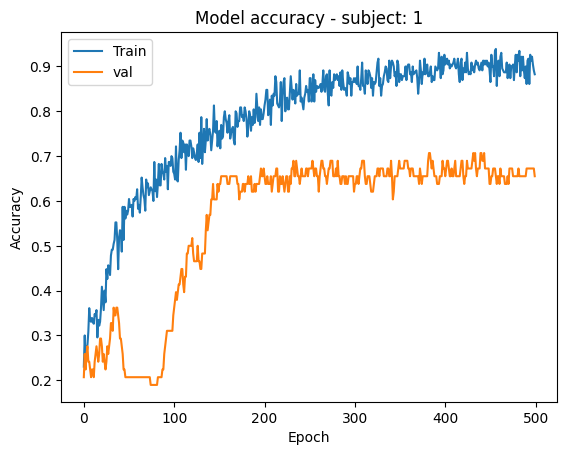

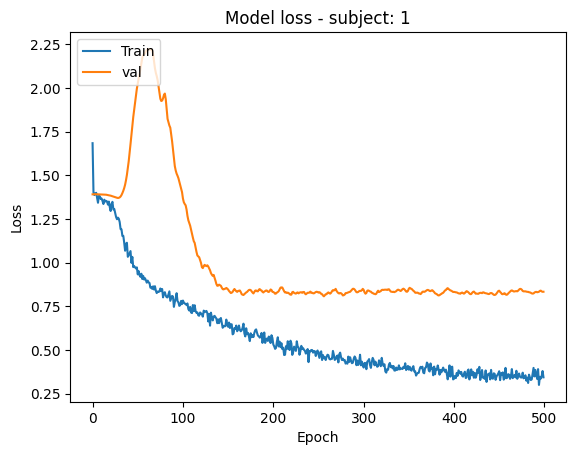


Training on subject  2


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)


After preprocessing X_train shape is:(230, 1, 22, 1125)
After preprocessing X_val shape is:(58, 1, 22, 1125)
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 469ms/step
Subject: 2   seed 1   time: 1.1 m   valid_acc: 0.6379   valid_loss: 0.830
Plot Learning Curves ....... 


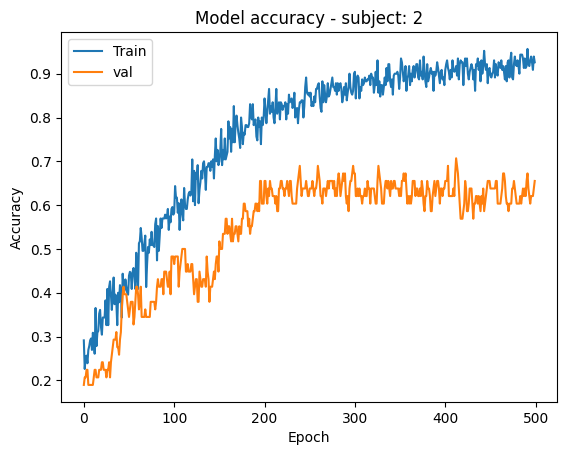

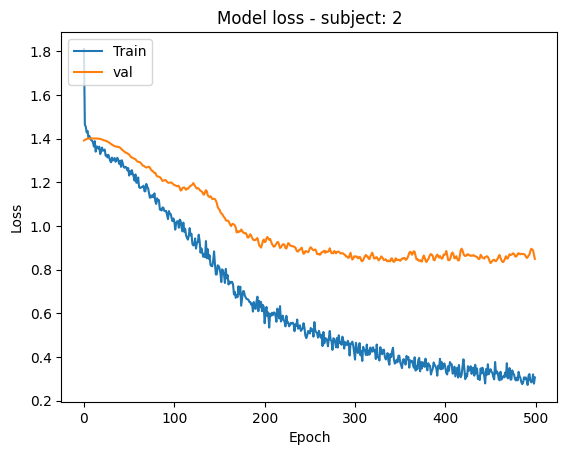


Training on subject  3


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)


After preprocessing X_train shape is:(230, 1, 22, 1125)
After preprocessing X_val shape is:(58, 1, 22, 1125)
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x72795411b0a0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more d

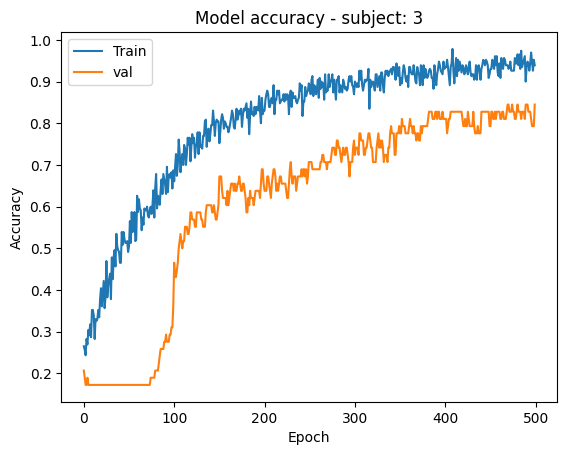

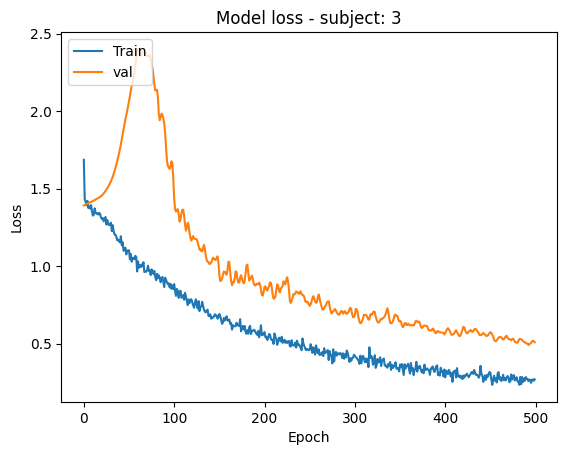


Training on subject  4


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)


After preprocessing X_train shape is:(230, 1, 22, 1125)
After preprocessing X_val shape is:(58, 1, 22, 1125)
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 474ms/step
Subject: 4   seed 1   time: 1.1 m   valid_acc: 0.5862   valid_loss: 1.084
Plot Learning Curves ....... 


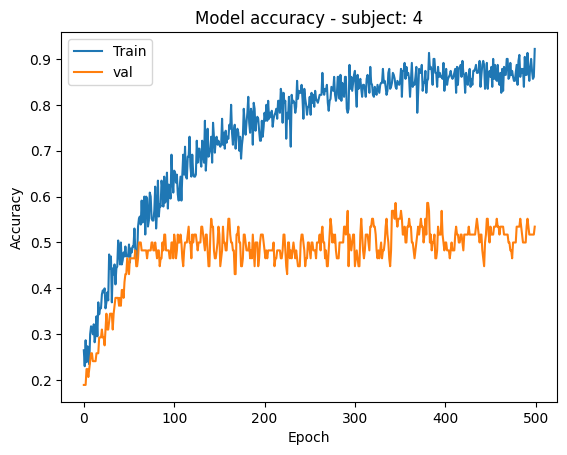

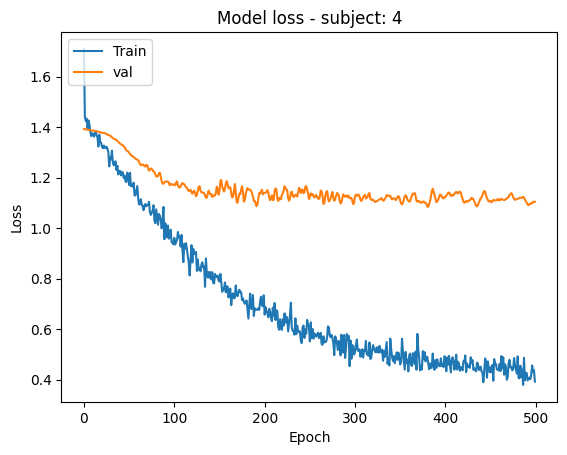


Training on subject  5


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)


After preprocessing X_train shape is:(230, 1, 22, 1125)
After preprocessing X_val shape is:(58, 1, 22, 1125)
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 471ms/step
Subject: 5   seed 1   time: 1.1 m   valid_acc: 0.7586   valid_loss: 0.706
Plot Learning Curves ....... 


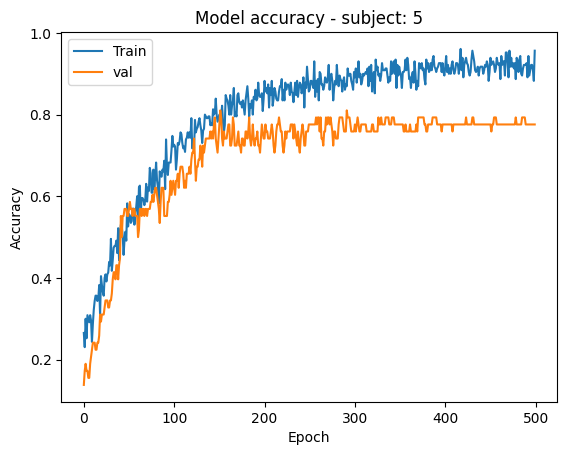

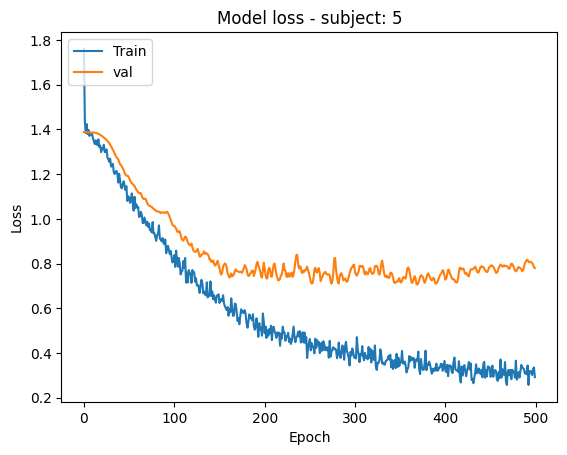


Training on subject  6


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)


After preprocessing X_train shape is:(230, 1, 22, 1125)
After preprocessing X_val shape is:(58, 1, 22, 1125)
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 458ms/step
Subject: 6   seed 1   time: 1.1 m   valid_acc: 0.7414   valid_loss: 0.755
Plot Learning Curves ....... 


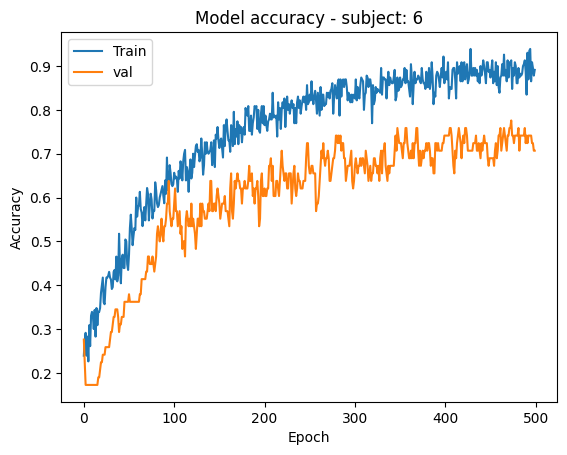

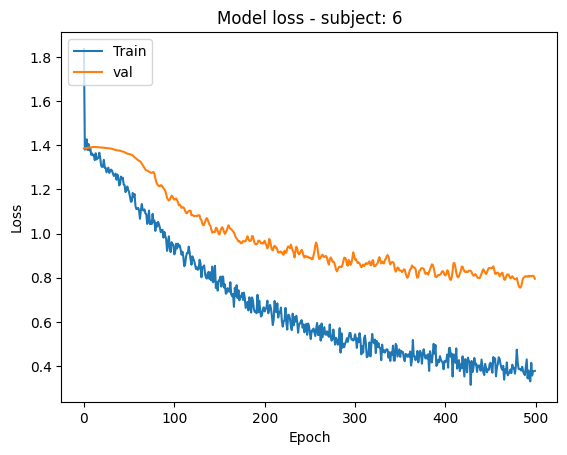


Training on subject  7


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)


After preprocessing X_train shape is:(230, 1, 22, 1125)
After preprocessing X_val shape is:(58, 1, 22, 1125)
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 466ms/step
Subject: 7   seed 1   time: 1.1 m   valid_acc: 0.9138   valid_loss: 0.263
Plot Learning Curves ....... 


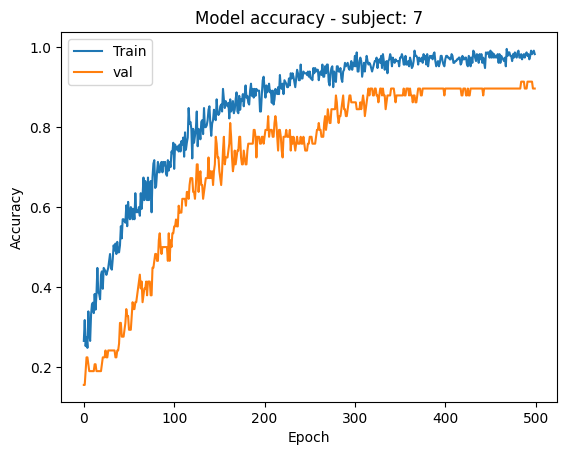

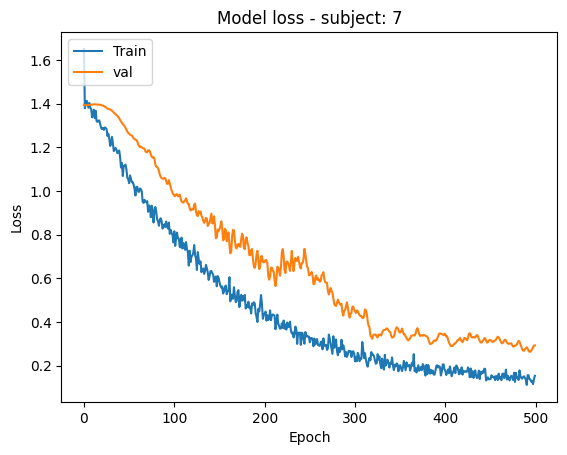


Training on subject  8


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)


After preprocessing X_train shape is:(230, 1, 22, 1125)
After preprocessing X_val shape is:(58, 1, 22, 1125)
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 465ms/step
Subject: 8   seed 1   time: 1.1 m   valid_acc: 0.8103   valid_loss: 0.463
Plot Learning Curves ....... 


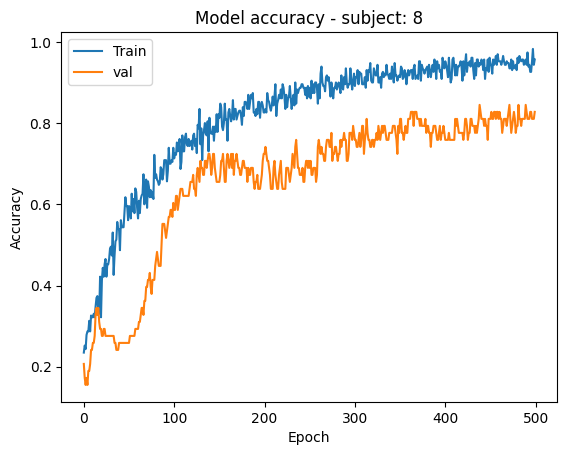

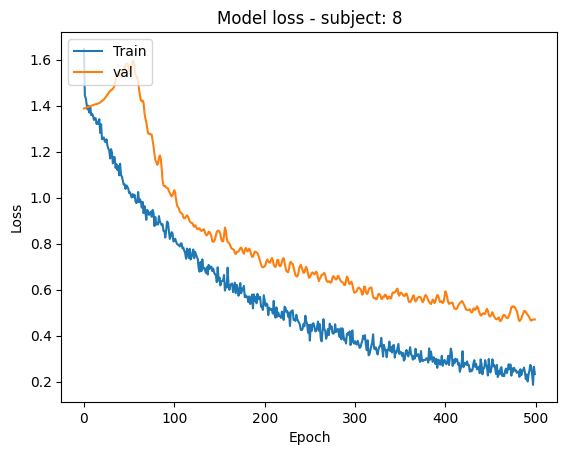


Training on subject  9


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)


After preprocessing X_train shape is:(230, 1, 22, 1125)
After preprocessing X_val shape is:(58, 1, 22, 1125)
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 465ms/step
Subject: 9   seed 1   time: 1.1 m   valid_acc: 0.8448   valid_loss: 0.434
Plot Learning Curves ....... 


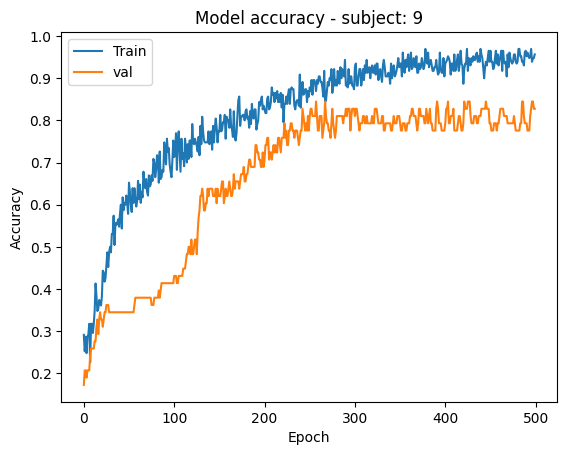

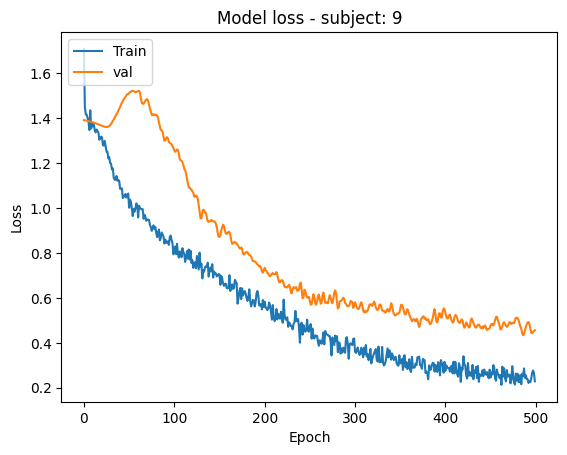


---------------------------------
Validation performance (acc %):
---------------------------------
         sub_1   sub_2   sub_3   sub_4   sub_5   sub_6   sub_7   sub_8   sub_9     average
         -----   -----   -----   -----   -----   -----   -----   -----   -----     -------
Seed 1:  67.24   63.79   82.76   58.62   75.86   74.14   91.38   81.03   84.48     75.48   
---------------------------------
Average acc - all seeds: 75.48 %

Train Time  - all seeds: 9.9 min
---------------------------------

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

---------------------------------
Test performance (acc & k-score):
---------------------------------
                  sub_1   sub_2   sub_3   s

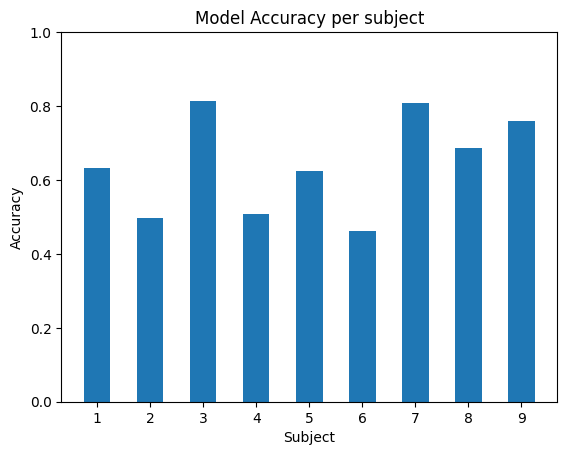

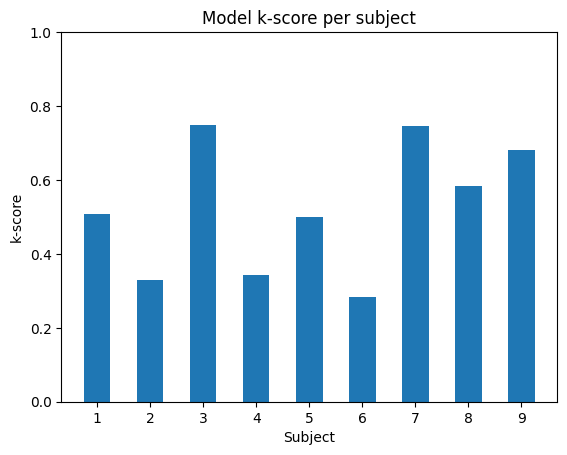

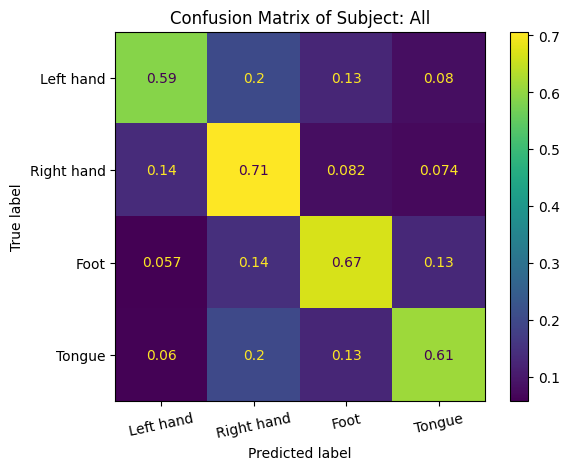

In [13]:
run("none")


Training on subject  1


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)
Lunghezza originale del segnale: (230, 1, 22, 1125)
Livello 1: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (12,), hi_d shape (12,)
Livello 2: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (13,), hi_d shape (13,)
Livello 3: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Livello 4: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Lunghezza del segnale ricostruito: (230, 1, 22, 1125)
Lunghezza originale del segnale: (58, 1, 22, 1125)
Livello 1: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (12,), hi_d shape (12,)
Livello 2: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (13,), hi_d shape (13,)
Livello 3: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Livello 4: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Lunghezza del segnale 

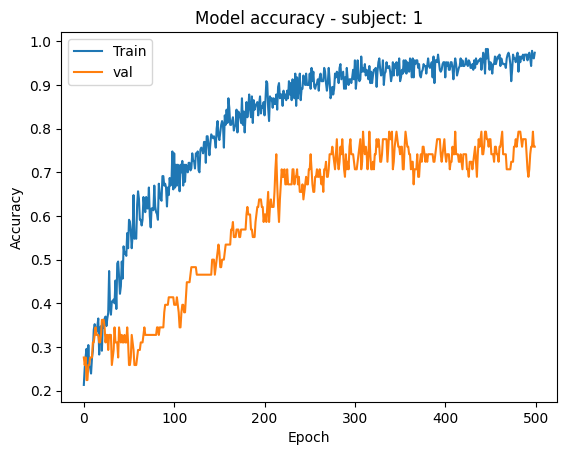

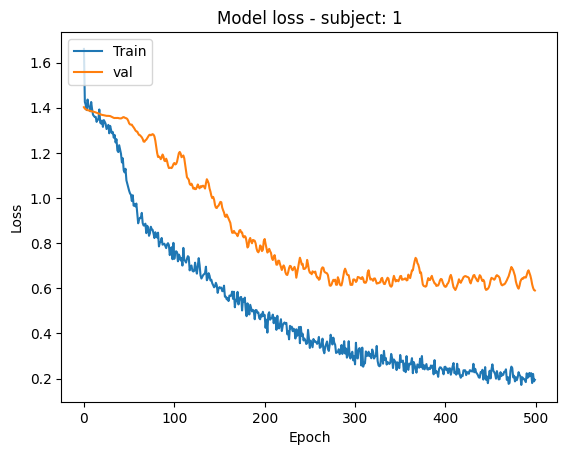


Training on subject  2


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)
Lunghezza originale del segnale: (230, 1, 22, 1125)
Livello 1: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (12,), hi_d shape (12,)
Livello 2: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (13,), hi_d shape (13,)
Livello 3: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Livello 4: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Lunghezza del segnale ricostruito: (230, 1, 22, 1125)
Lunghezza originale del segnale: (58, 1, 22, 1125)
Livello 1: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (12,), hi_d shape (12,)
Livello 2: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (13,), hi_d shape (13,)
Livello 3: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Livello 4: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Lunghezza del segnale 

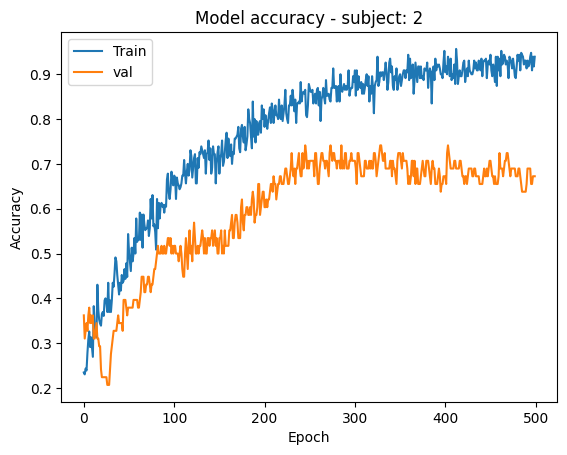

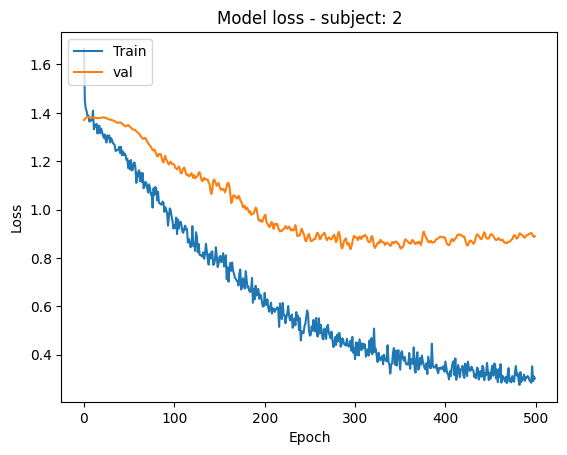


Training on subject  3


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)
Lunghezza originale del segnale: (230, 1, 22, 1125)
Livello 1: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (12,), hi_d shape (12,)
Livello 2: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (13,), hi_d shape (13,)
Livello 3: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Livello 4: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Lunghezza del segnale ricostruito: (230, 1, 22, 1125)
Lunghezza originale del segnale: (58, 1, 22, 1125)
Livello 1: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (12,), hi_d shape (12,)
Livello 2: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (13,), hi_d shape (13,)
Livello 3: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Livello 4: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Lunghezza del segnale 

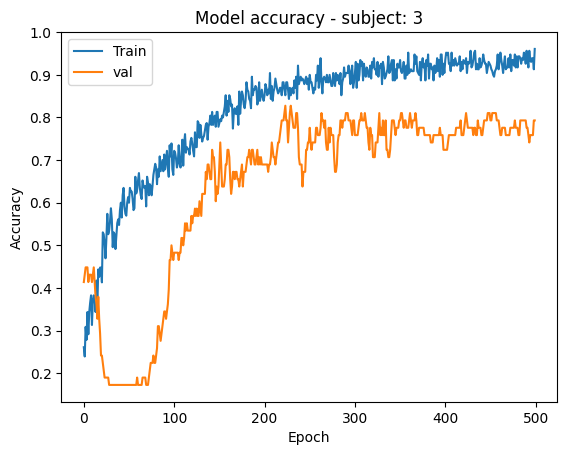

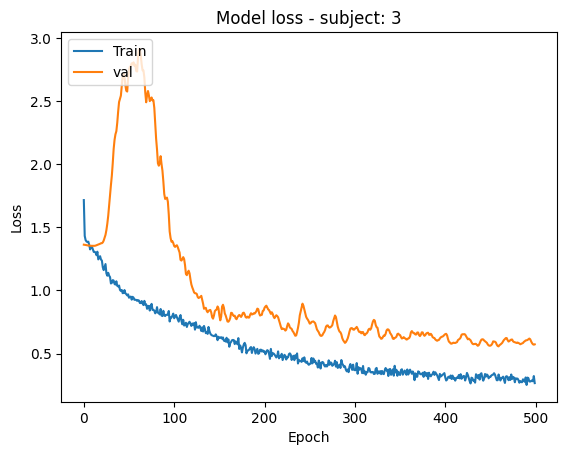


Training on subject  4


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)
Lunghezza originale del segnale: (230, 1, 22, 1125)
Livello 1: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (12,), hi_d shape (12,)
Livello 2: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (13,), hi_d shape (13,)
Livello 3: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Livello 4: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Lunghezza del segnale ricostruito: (230, 1, 22, 1125)
Lunghezza originale del segnale: (58, 1, 22, 1125)
Livello 1: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (12,), hi_d shape (12,)
Livello 2: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (13,), hi_d shape (13,)
Livello 3: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Livello 4: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Lunghezza del segnale 

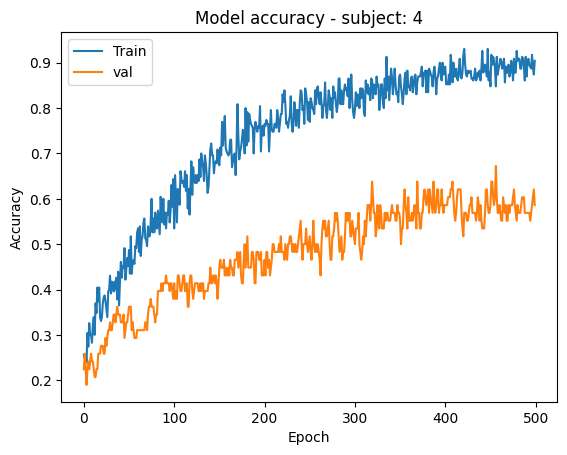

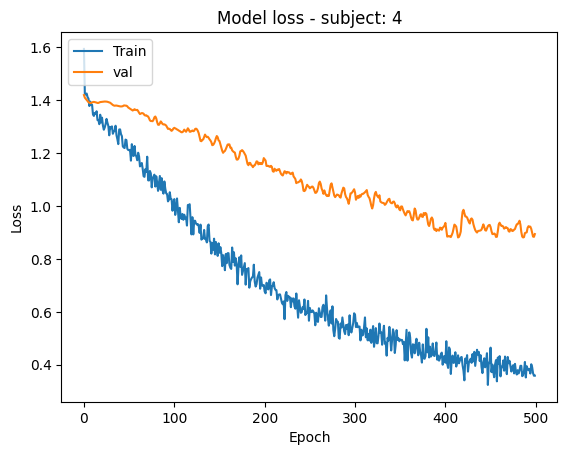


Training on subject  5


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)
Lunghezza originale del segnale: (230, 1, 22, 1125)
Livello 1: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (12,), hi_d shape (12,)
Livello 2: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (13,), hi_d shape (13,)
Livello 3: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Livello 4: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Lunghezza del segnale ricostruito: (230, 1, 22, 1125)
Lunghezza originale del segnale: (58, 1, 22, 1125)
Livello 1: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (12,), hi_d shape (12,)
Livello 2: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (13,), hi_d shape (13,)
Livello 3: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Livello 4: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Lunghezza del segnale 

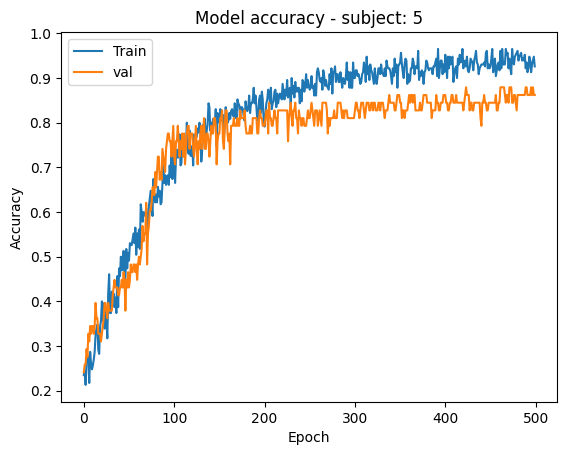

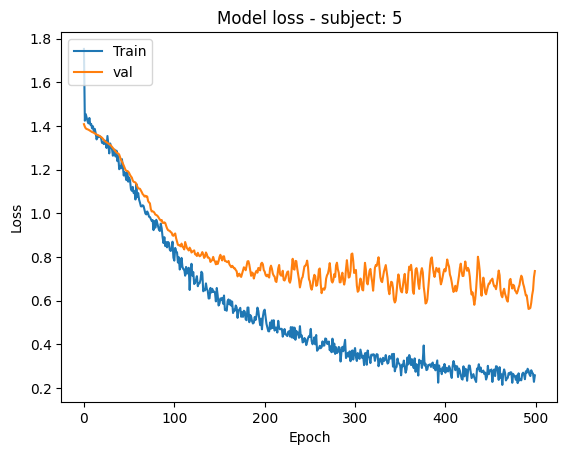


Training on subject  6


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)
Lunghezza originale del segnale: (230, 1, 22, 1125)
Livello 1: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (12,), hi_d shape (12,)
Livello 2: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (13,), hi_d shape (13,)
Livello 3: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Livello 4: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Lunghezza del segnale ricostruito: (230, 1, 22, 1125)
Lunghezza originale del segnale: (58, 1, 22, 1125)
Livello 1: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (12,), hi_d shape (12,)
Livello 2: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (13,), hi_d shape (13,)
Livello 3: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Livello 4: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Lunghezza del segnale 

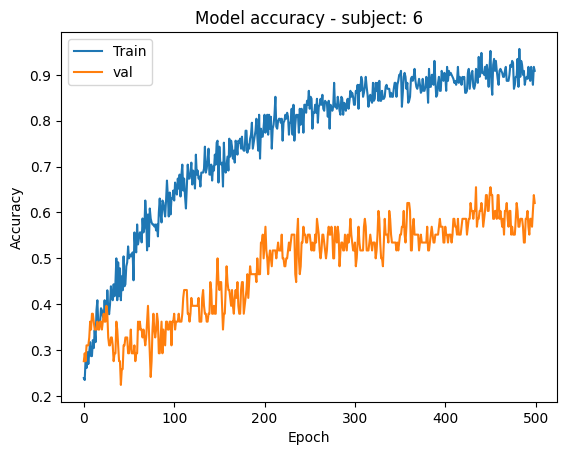

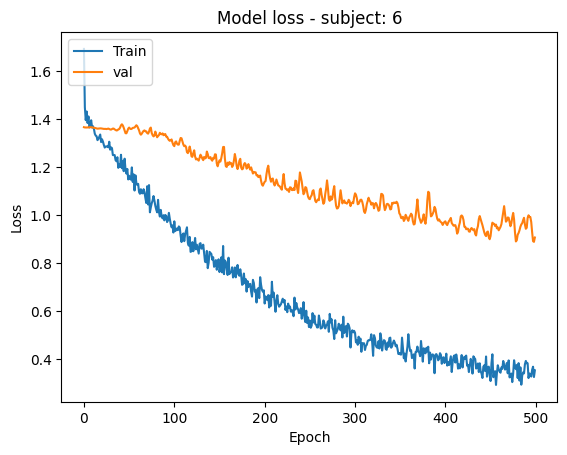


Training on subject  7


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)
Lunghezza originale del segnale: (230, 1, 22, 1125)
Livello 1: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (12,), hi_d shape (12,)
Livello 2: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (13,), hi_d shape (13,)
Livello 3: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Livello 4: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Lunghezza del segnale ricostruito: (230, 1, 22, 1125)
Lunghezza originale del segnale: (58, 1, 22, 1125)
Livello 1: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (12,), hi_d shape (12,)
Livello 2: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (13,), hi_d shape (13,)
Livello 3: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Livello 4: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Lunghezza del segnale 

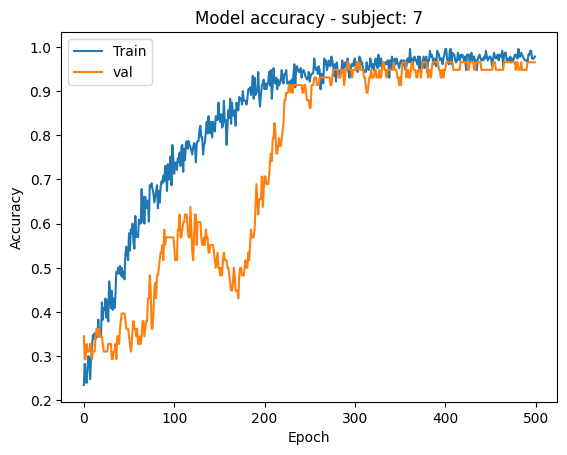

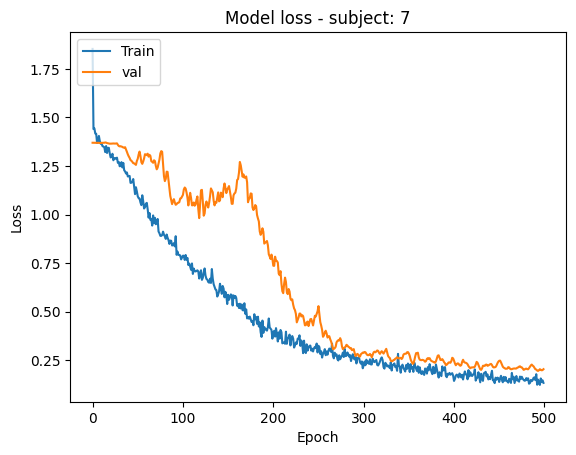


Training on subject  8


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)
Lunghezza originale del segnale: (230, 1, 22, 1125)
Livello 1: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (12,), hi_d shape (12,)
Livello 2: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (13,), hi_d shape (13,)
Livello 3: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Livello 4: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Lunghezza del segnale ricostruito: (230, 1, 22, 1125)
Lunghezza originale del segnale: (58, 1, 22, 1125)
Livello 1: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (12,), hi_d shape (12,)
Livello 2: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (13,), hi_d shape (13,)
Livello 3: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Livello 4: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Lunghezza del segnale 

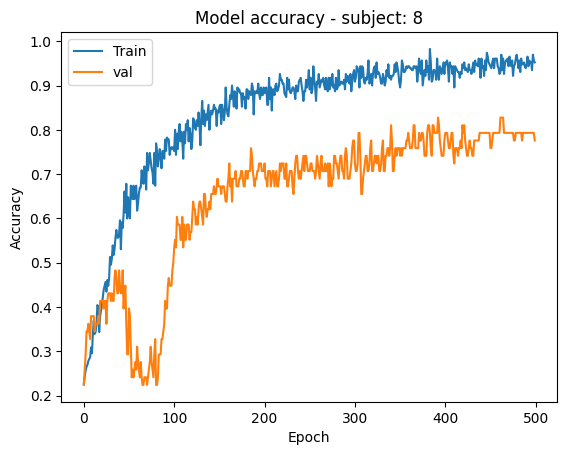

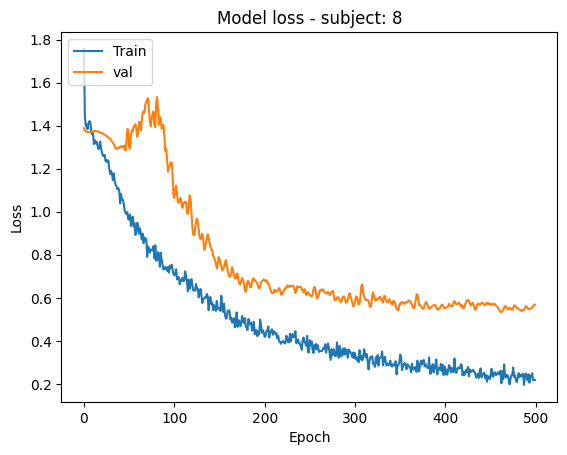


Training on subject  9


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)
Lunghezza originale del segnale: (230, 1, 22, 1125)
Livello 1: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (12,), hi_d shape (12,)
Livello 2: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (13,), hi_d shape (13,)
Livello 3: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Livello 4: coeffs_approx shape (230, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Lunghezza del segnale ricostruito: (230, 1, 22, 1125)
Lunghezza originale del segnale: (58, 1, 22, 1125)
Livello 1: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (12,), hi_d shape (12,)
Livello 2: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (13,), hi_d shape (13,)
Livello 3: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Livello 4: coeffs_approx shape (58, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Lunghezza del segnale 

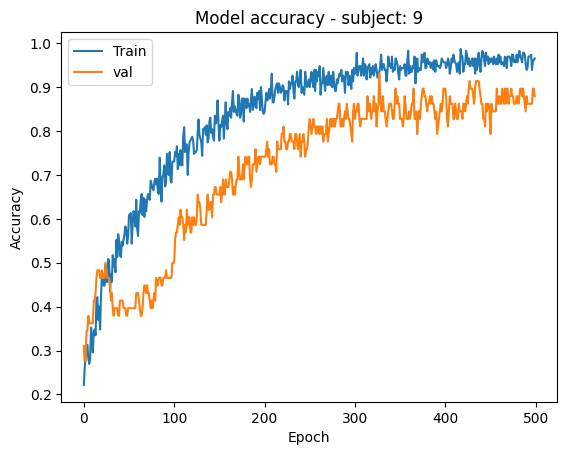

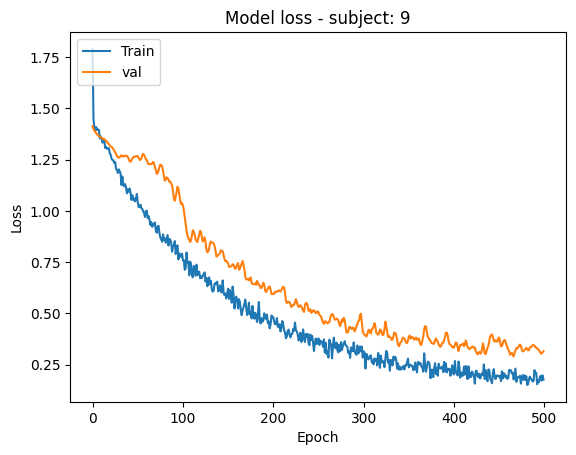


---------------------------------
Validation performance (acc %):
---------------------------------
         sub_1   sub_2   sub_3   sub_4   sub_5   sub_6   sub_7   sub_8   sub_9     average
         -----   -----   -----   -----   -----   -----   -----   -----   -----     -------
Seed 1:  75.86   70.69   79.31   60.34   86.21   63.79   96.55   82.76   89.66     78.35   
---------------------------------
Average acc - all seeds: 78.35 %

Train Time  - all seeds: 9.9 min
---------------------------------

Lunghezza originale del segnale: (288, 1, 22, 1125)
Livello 1: coeffs_approx shape (288, 1, 22, 1125), lo_d shape (12,), hi_d shape (12,)
Livello 2: coeffs_approx shape (288, 1, 22, 1125), lo_d shape (13,), hi_d shape (13,)
Livello 3: coeffs_approx shape (288, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Livello 4: coeffs_approx shape (288, 1, 22, 1125), lo_d shape (14,), hi_d shape (14,)
Lunghezza del segnale ricostruito: (288, 1, 22, 1125)
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  


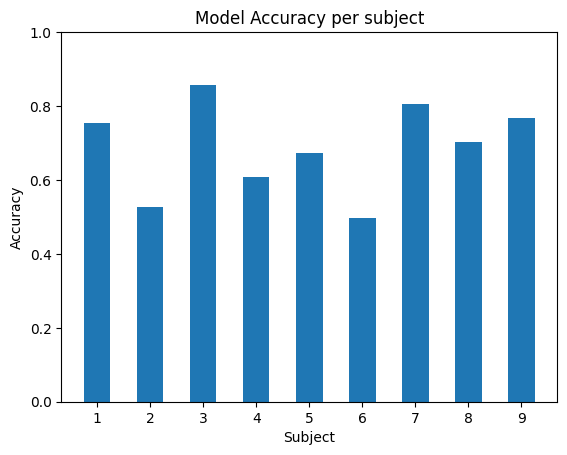

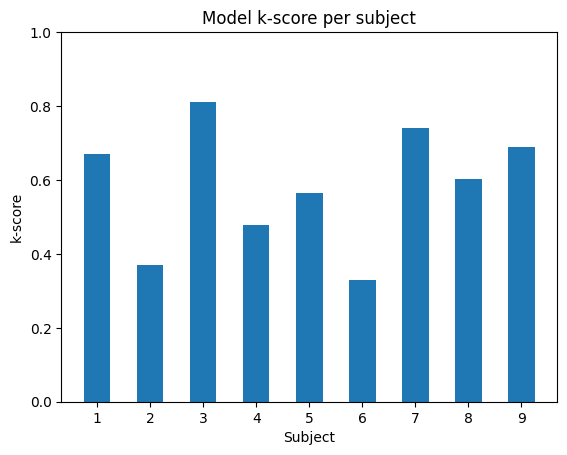

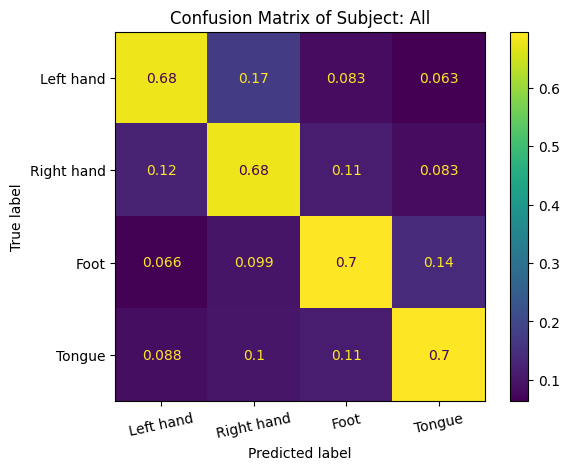

In [14]:
run("rdwt")


Training on subject  1




Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)
Lunghezza originale: 1125
Lunghezza coefficiente di approssimazione: 230
Lunghezza ricostruita: 230
Lunghezza originale: 1125
Lunghezza coefficiente di approssimazione: 58
Lunghezza ricostruita: 58


After preprocessing X_train shape is:(230, 1, 22, 1126)
After preprocessing X_val shape is:(58, 1, 22, 1126)
New X_train shape is: (230, 1, 22, 1125)
New X_val shape is: (58, 1, 22, 1125)


I0000 00:00:1761581854.179956  808450 service.cc:152] XLA service 0x75788001e2a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761581854.179979  808450 service.cc:160]   StreamExecutor device (0): NVIDIA RTX 6000 Ada Generation, Compute Capability 8.9
2025-10-27 17:17:34.256727: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1761581854.641729  808450 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-10-27 17:17:35.377096: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.68GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-10-27 17:17:35.678657: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) 

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step

2025-10-27 17:18:31.611270: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 706.92MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 574ms/step
Subject: 1   seed 1   time: 1.0 m   valid_acc: 0.6552   valid_loss: 0.992
Plot Learning Curves ....... 


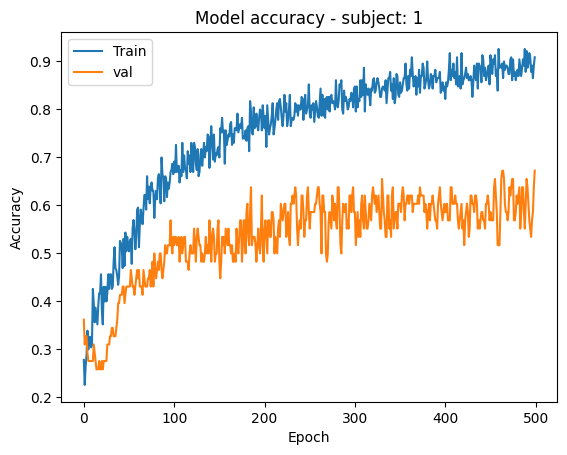

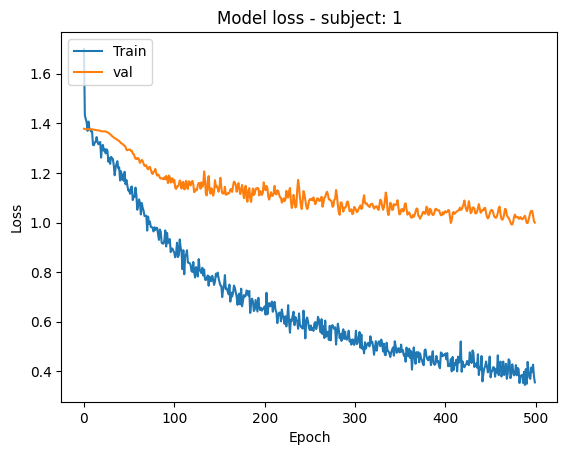


Training on subject  2


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)
Lunghezza originale: 1125
Lunghezza coefficiente di approssimazione: 230
Lunghezza ricostruita: 230
Lunghezza originale: 1125
Lunghezza coefficiente di approssimazione: 58
Lunghezza ricostruita: 58


After preprocessing X_train shape is:(230, 1, 22, 1126)
After preprocessing X_val shape is:(58, 1, 22, 1126)
New X_train shape is: (230, 1, 22, 1125)
New X_val shape is: (58, 1, 22, 1125)
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 469ms/step
Subject: 2   seed 1   time: 1.0 m   valid_acc: 0.4483   valid_loss: 1.166
Plot Learning Curves ....... 


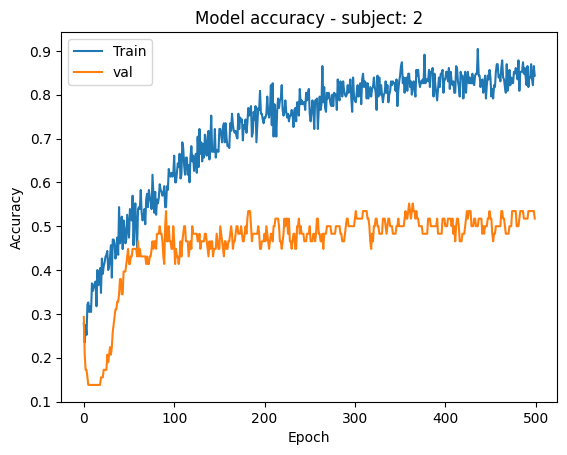

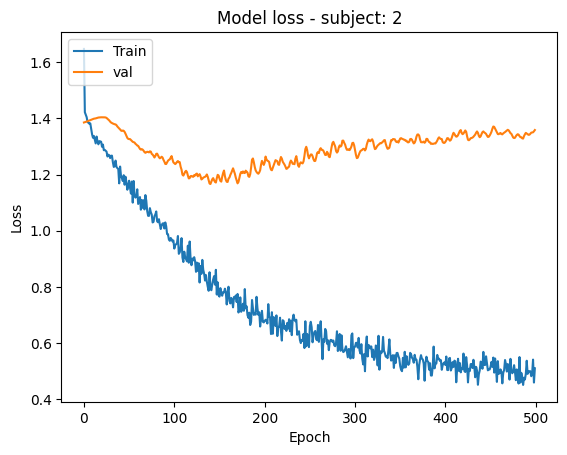


Training on subject  3


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)
Lunghezza originale: 1125
Lunghezza coefficiente di approssimazione: 230
Lunghezza ricostruita: 230
Lunghezza originale: 1125
Lunghezza coefficiente di approssimazione: 58
Lunghezza ricostruita: 58


After preprocessing X_train shape is:(230, 1, 22, 1126)
After preprocessing X_val shape is:(58, 1, 22, 1126)
New X_train shape is: (230, 1, 22, 1125)
New X_val shape is: (58, 1, 22, 1125)
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x757b3242b400> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.funct

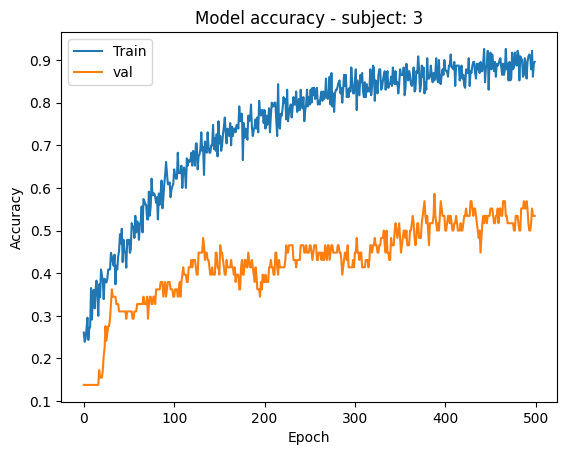

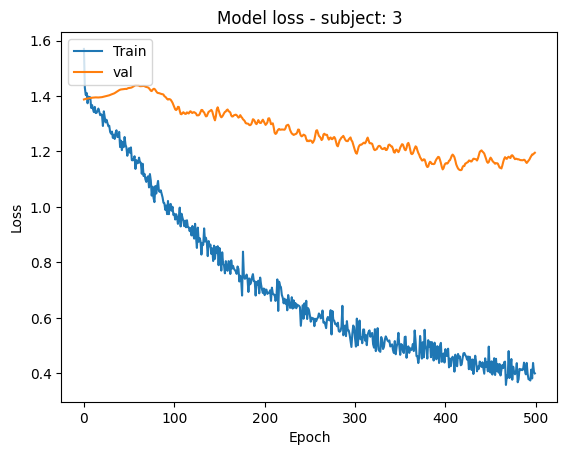


Training on subject  4


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)
Lunghezza originale: 1125
Lunghezza coefficiente di approssimazione: 230
Lunghezza ricostruita: 230
Lunghezza originale: 1125
Lunghezza coefficiente di approssimazione: 58
Lunghezza ricostruita: 58


After preprocessing X_train shape is:(230, 1, 22, 1126)
After preprocessing X_val shape is:(58, 1, 22, 1126)
New X_train shape is: (230, 1, 22, 1125)
New X_val shape is: (58, 1, 22, 1125)
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 454ms/step
Subject: 4   seed 1   time: 1.0 m   valid_acc: 0.4310   valid_loss: 1.303
Plot Learning Curves ....... 


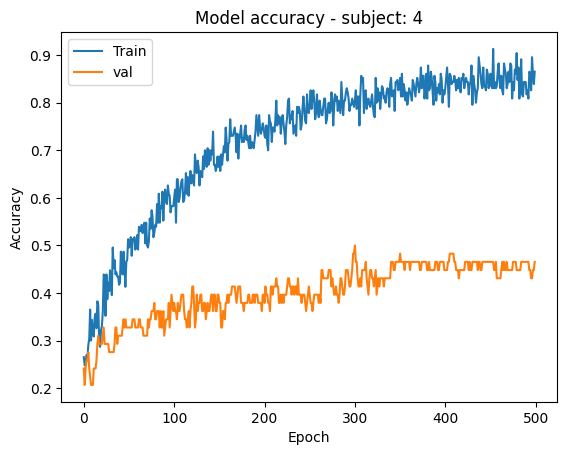

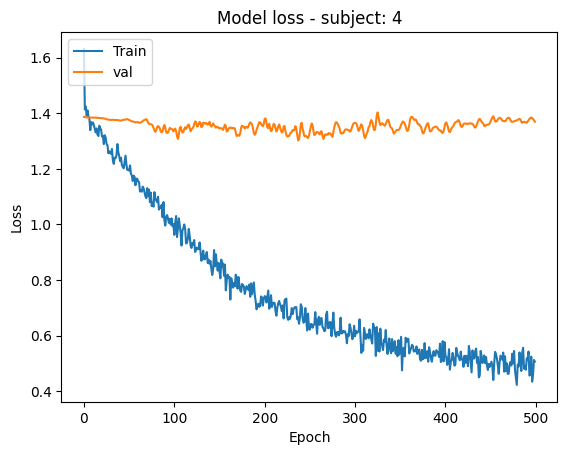


Training on subject  5


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)
Lunghezza originale: 1125
Lunghezza coefficiente di approssimazione: 230
Lunghezza ricostruita: 230
Lunghezza originale: 1125
Lunghezza coefficiente di approssimazione: 58
Lunghezza ricostruita: 58


After preprocessing X_train shape is:(230, 1, 22, 1126)
After preprocessing X_val shape is:(58, 1, 22, 1126)
New X_train shape is: (230, 1, 22, 1125)
New X_val shape is: (58, 1, 22, 1125)
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 476ms/step
Subject: 5   seed 1   time: 1.0 m   valid_acc: 0.7414   valid_loss: 0.705
Plot Learning Curves ....... 


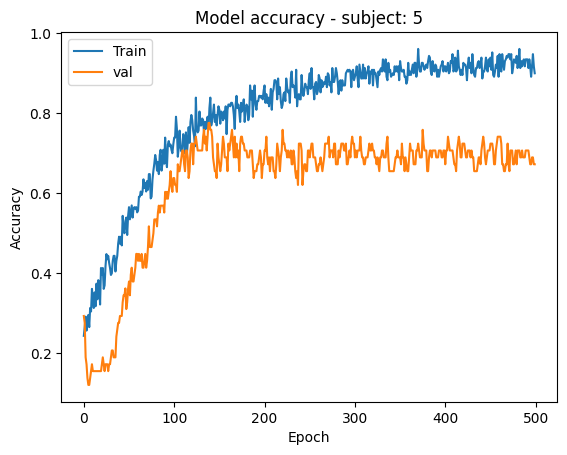

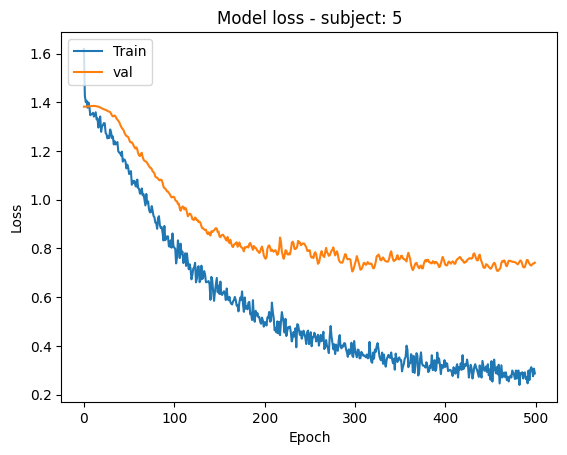


Training on subject  6


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)
Lunghezza originale: 1125
Lunghezza coefficiente di approssimazione: 230
Lunghezza ricostruita: 230
Lunghezza originale: 1125
Lunghezza coefficiente di approssimazione: 58
Lunghezza ricostruita: 58


After preprocessing X_train shape is:(230, 1, 22, 1126)
After preprocessing X_val shape is:(58, 1, 22, 1126)
New X_train shape is: (230, 1, 22, 1125)
New X_val shape is: (58, 1, 22, 1125)
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 465ms/step
Subject: 6   seed 1   time: 1.0 m   valid_acc: 0.5862   valid_loss: 1.035
Plot Learning Curves ....... 


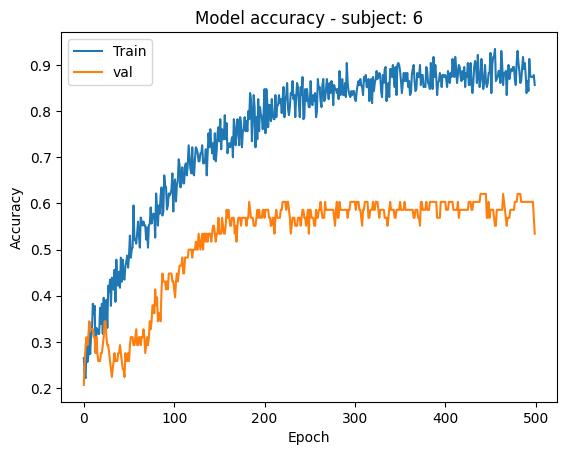

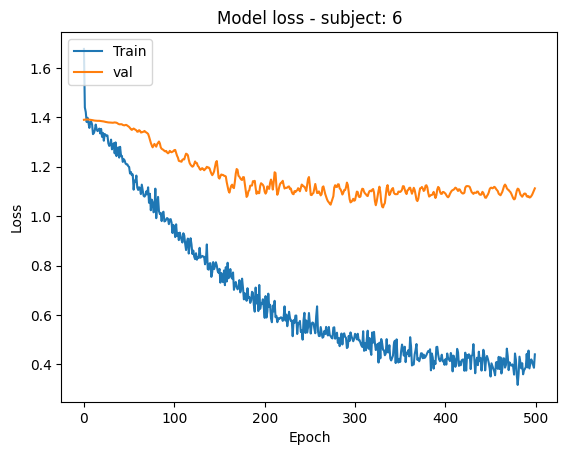


Training on subject  7


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)
Lunghezza originale: 1125
Lunghezza coefficiente di approssimazione: 230
Lunghezza ricostruita: 230
Lunghezza originale: 1125
Lunghezza coefficiente di approssimazione: 58
Lunghezza ricostruita: 58


After preprocessing X_train shape is:(230, 1, 22, 1126)
After preprocessing X_val shape is:(58, 1, 22, 1126)
New X_train shape is: (230, 1, 22, 1125)
New X_val shape is: (58, 1, 22, 1125)
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 454ms/step
Subject: 7   seed 1   time: 1.0 m   valid_acc: 0.6034   valid_loss: 0.770
Plot Learning Curves ....... 


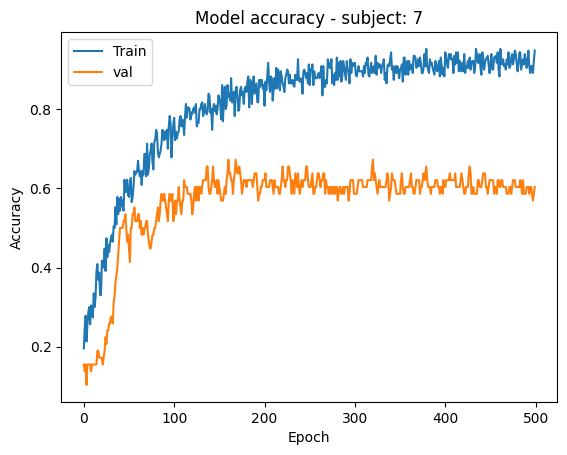

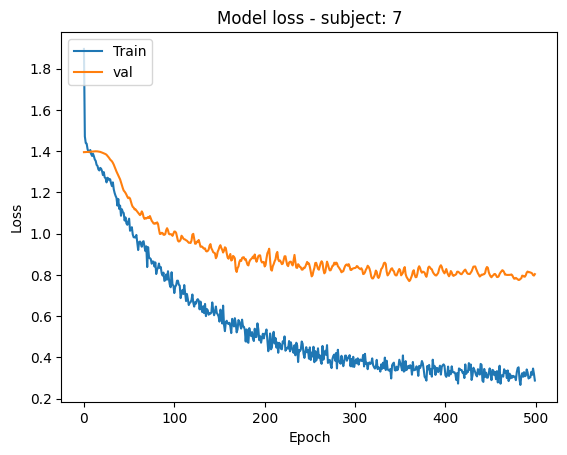


Training on subject  8


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)
Lunghezza originale: 1125
Lunghezza coefficiente di approssimazione: 230
Lunghezza ricostruita: 230
Lunghezza originale: 1125
Lunghezza coefficiente di approssimazione: 58
Lunghezza ricostruita: 58


After preprocessing X_train shape is:(230, 1, 22, 1126)
After preprocessing X_val shape is:(58, 1, 22, 1126)
New X_train shape is: (230, 1, 22, 1125)
New X_val shape is: (58, 1, 22, 1125)
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 473ms/step
Subject: 8   seed 1   time: 1.0 m   valid_acc: 0.6897   valid_loss: 0.844
Plot Learning Curves ....... 


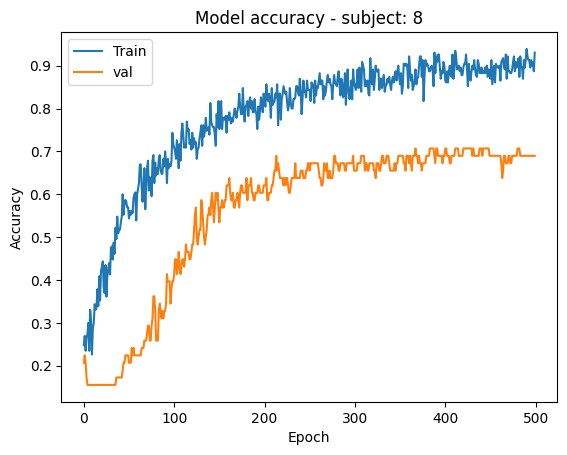

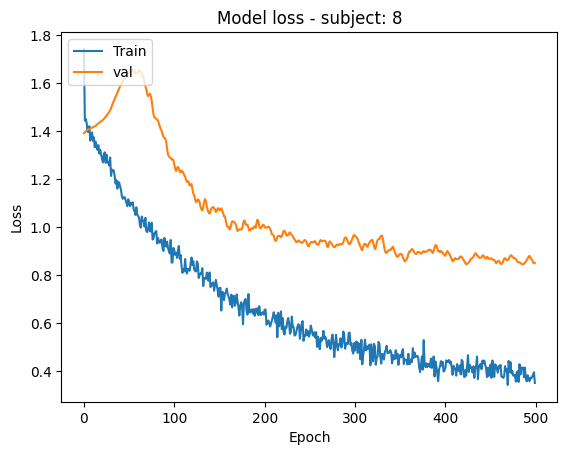


Training on subject  9


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)
Lunghezza originale: 1125
Lunghezza coefficiente di approssimazione: 230
Lunghezza ricostruita: 230
Lunghezza originale: 1125
Lunghezza coefficiente di approssimazione: 58
Lunghezza ricostruita: 58


After preprocessing X_train shape is:(230, 1, 22, 1126)
After preprocessing X_val shape is:(58, 1, 22, 1126)
New X_train shape is: (230, 1, 22, 1125)
New X_val shape is: (58, 1, 22, 1125)
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 451ms/step
Subject: 9   seed 1   time: 1.0 m   valid_acc: 0.7586   valid_loss: 0.602
Plot Learning Curves ....... 


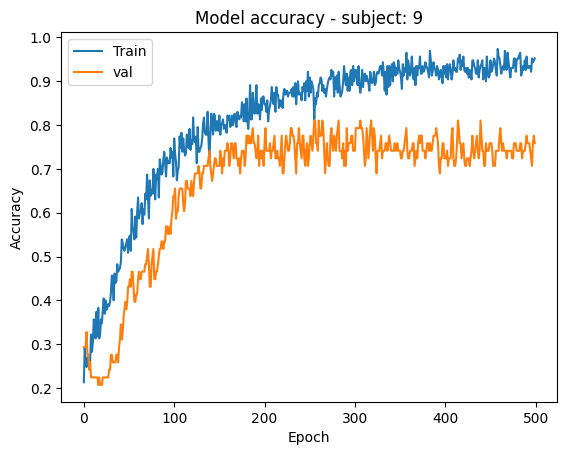

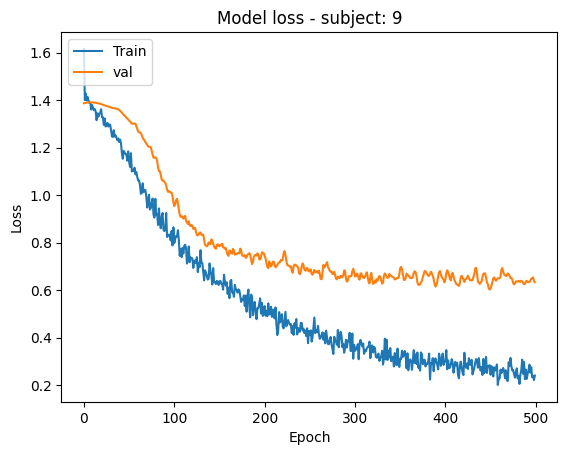


---------------------------------
Validation performance (acc %):
---------------------------------
         sub_1   sub_2   sub_3   sub_4   sub_5   sub_6   sub_7   sub_8   sub_9     average
         -----   -----   -----   -----   -----   -----   -----   -----   -----     -------
Seed 1:  65.52   44.83   51.72   43.10   74.14   58.62   60.34   68.97   75.86     60.34   
---------------------------------
Average acc - all seeds: 60.34 %

Train Time  - all seeds: 9.1 min
---------------------------------

Lunghezza originale: 1125
Lunghezza coefficiente di approssimazione: 288
Lunghezza ricostruita: 288
New X_test shape is: (288, 1, 22, 1125)
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  
Lunghezza originale: 1125
Lunghezza coefficiente di approssimazione: 288
Lunghezza ricostruita: 288
New X_test shape is: (288, 1, 22, 1125)
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Lunghezza originale: 1125
Lunghezza coefficiente di approssimazione: 288
Lunghezza ricostruita: 288
New X_test shape is: (288, 1, 22

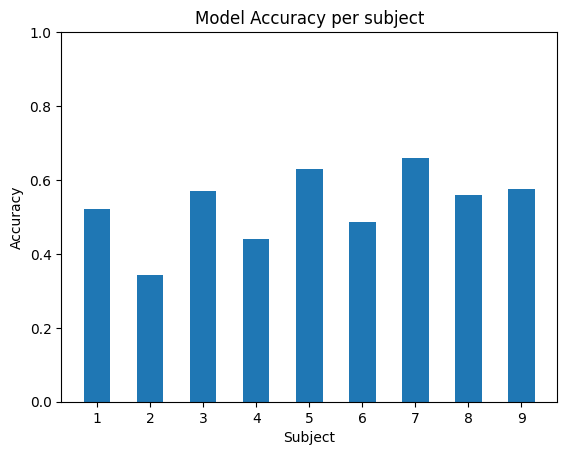

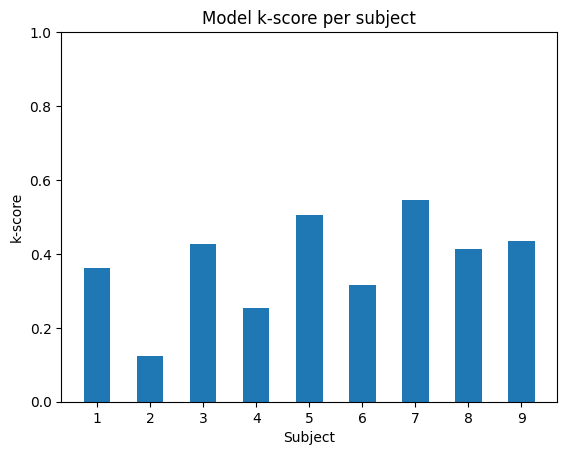

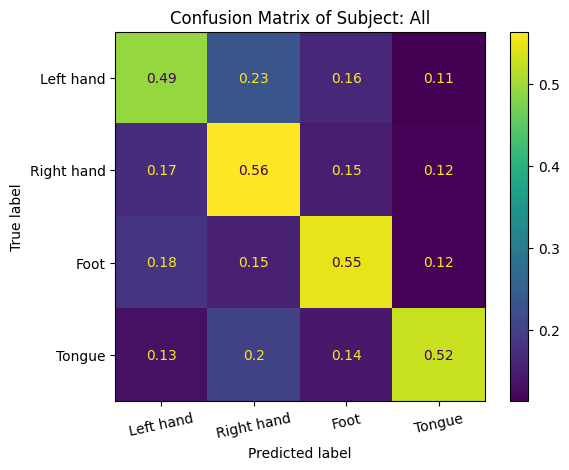

In [26]:
run("db4_soft")


Training on subject  1


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)


After preprocessing X_train shape is:(230, 1, 22, 1126)
After preprocessing X_val shape is:(58, 1, 22, 1126)
New X_train shape is: (230, 1, 22, 1125)
New X_val shape is: (58, 1, 22, 1125)
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 479ms/step
Subject: 1   seed 1   time: 1.0 m   valid_acc: 0.5000   valid_loss: 1.195
Plot Learning Curves ....... 


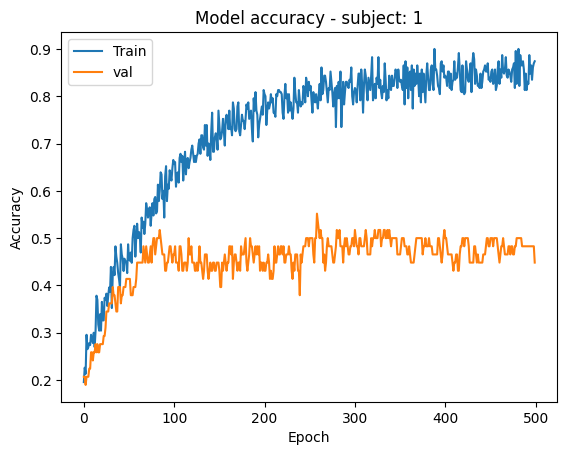

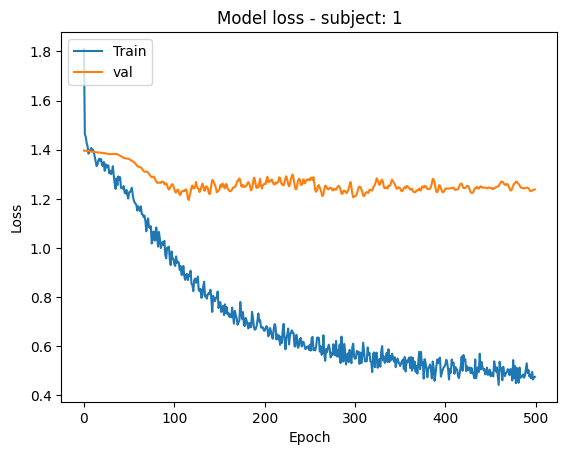


Training on subject  2


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)


After preprocessing X_train shape is:(230, 1, 22, 1126)
After preprocessing X_val shape is:(58, 1, 22, 1126)
New X_train shape is: (230, 1, 22, 1125)
New X_val shape is: (58, 1, 22, 1125)
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 463ms/step
Subject: 2   seed 1   time: 1.0 m   valid_acc: 0.6034   valid_loss: 1.003
Plot Learning Curves ....... 


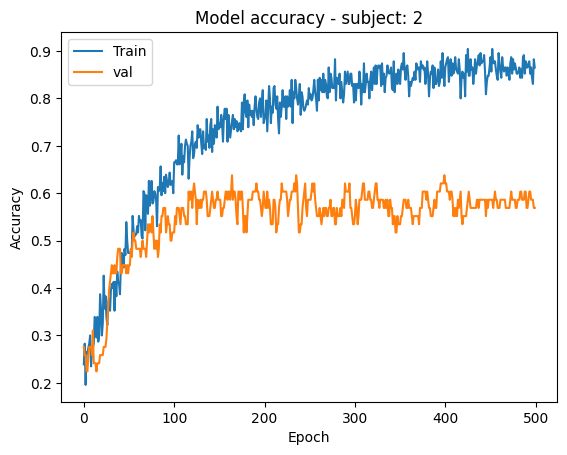

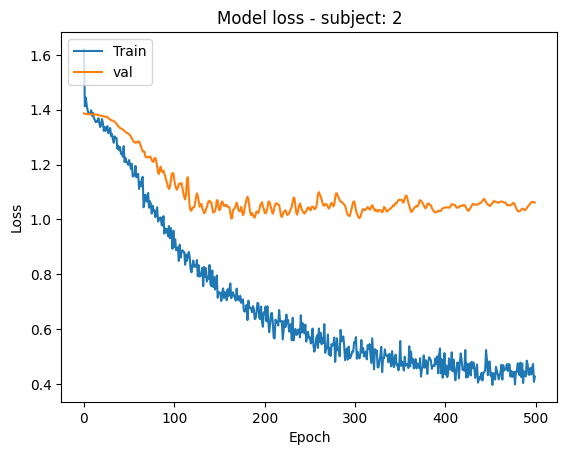


Training on subject  3


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)


After preprocessing X_train shape is:(230, 1, 22, 1126)
After preprocessing X_val shape is:(58, 1, 22, 1126)
New X_train shape is: (230, 1, 22, 1125)
New X_val shape is: (58, 1, 22, 1125)
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 453ms/step
Subject: 3   seed 1   time: 1.0 m   valid_acc: 0.6552   valid_loss: 1.014
Plot Learning Curves ....... 


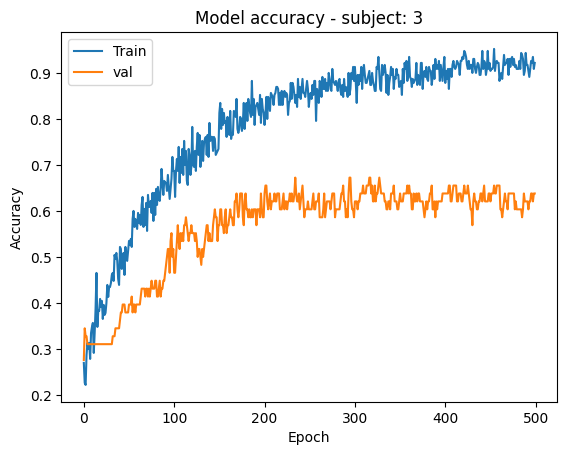

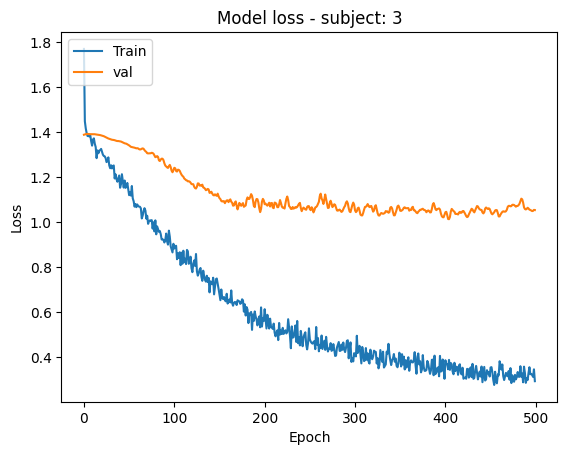


Training on subject  4


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)


After preprocessing X_train shape is:(230, 1, 22, 1126)
After preprocessing X_val shape is:(58, 1, 22, 1126)
New X_train shape is: (230, 1, 22, 1125)
New X_val shape is: (58, 1, 22, 1125)
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 480ms/step
Subject: 4   seed 1   time: 1.0 m   valid_acc: 0.6724   valid_loss: 0.973
Plot Learning Curves ....... 


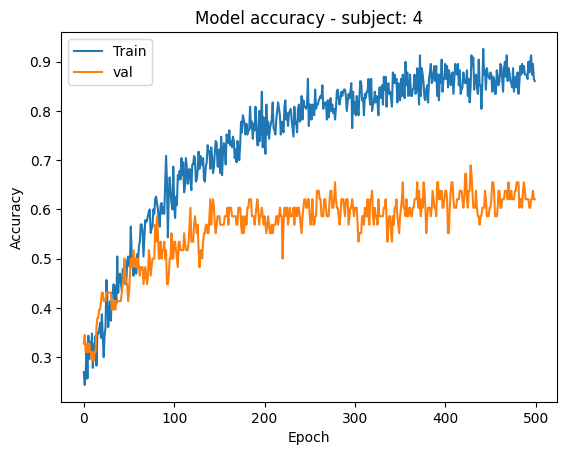

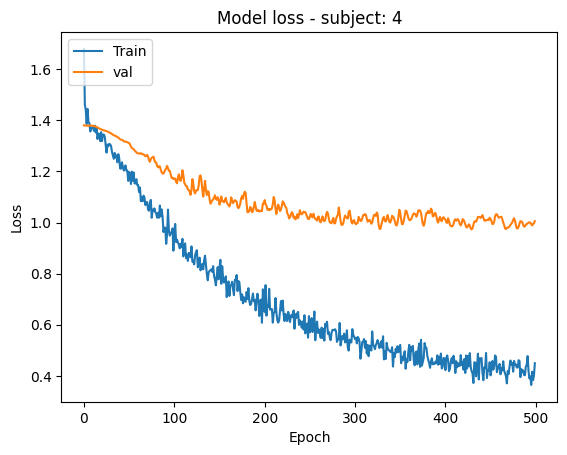


Training on subject  5


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)


After preprocessing X_train shape is:(230, 1, 22, 1126)
After preprocessing X_val shape is:(58, 1, 22, 1126)
New X_train shape is: (230, 1, 22, 1125)
New X_val shape is: (58, 1, 22, 1125)
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 441ms/step
Subject: 5   seed 1   time: 1.0 m   valid_acc: 0.7414   valid_loss: 0.655
Plot Learning Curves ....... 


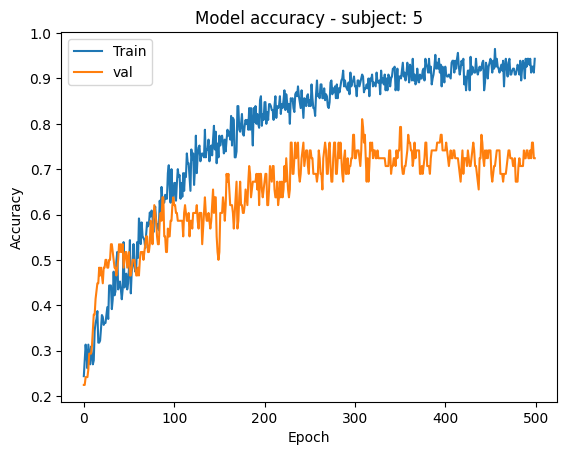

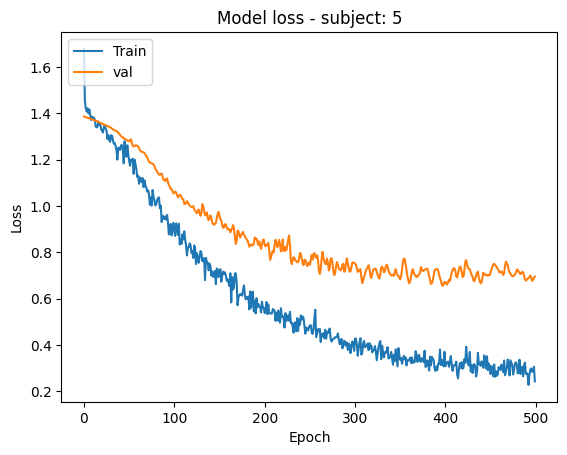


Training on subject  6


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)


After preprocessing X_train shape is:(230, 1, 22, 1126)
After preprocessing X_val shape is:(58, 1, 22, 1126)
New X_train shape is: (230, 1, 22, 1125)
New X_val shape is: (58, 1, 22, 1125)
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 463ms/step
Subject: 6   seed 1   time: 1.0 m   valid_acc: 0.5862   valid_loss: 0.986
Plot Learning Curves ....... 


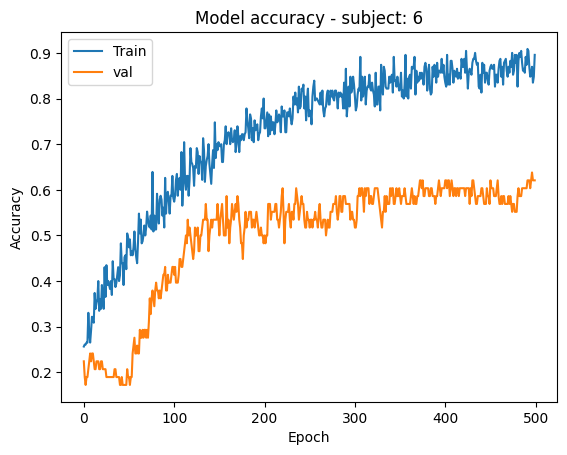

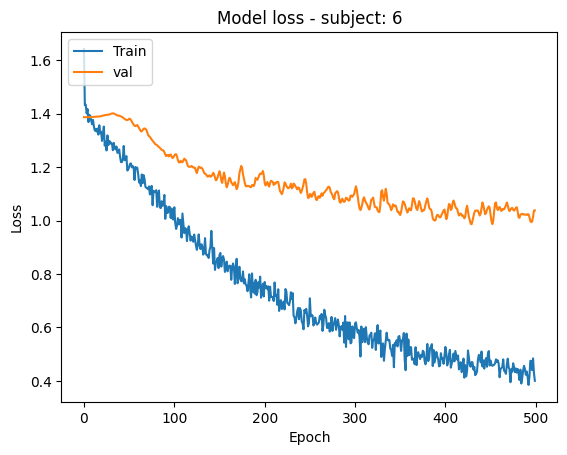


Training on subject  7


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)


After preprocessing X_train shape is:(230, 1, 22, 1126)
After preprocessing X_val shape is:(58, 1, 22, 1126)
New X_train shape is: (230, 1, 22, 1125)
New X_val shape is: (58, 1, 22, 1125)
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 464ms/step
Subject: 7   seed 1   time: 1.0 m   valid_acc: 0.7414   valid_loss: 0.642
Plot Learning Curves ....... 


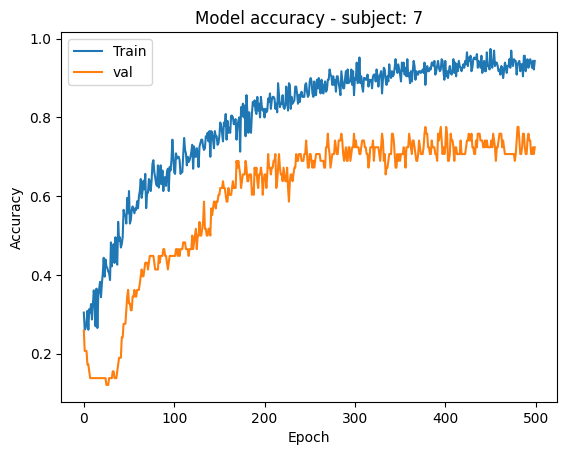

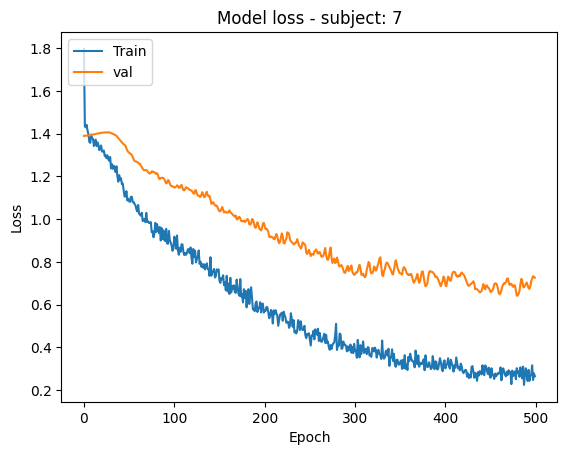


Training on subject  8


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)


After preprocessing X_train shape is:(230, 1, 22, 1126)
After preprocessing X_val shape is:(58, 1, 22, 1126)
New X_train shape is: (230, 1, 22, 1125)
New X_val shape is: (58, 1, 22, 1125)
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 469ms/step
Subject: 8   seed 1   time: 1.0 m   valid_acc: 0.6379   valid_loss: 0.924
Plot Learning Curves ....... 


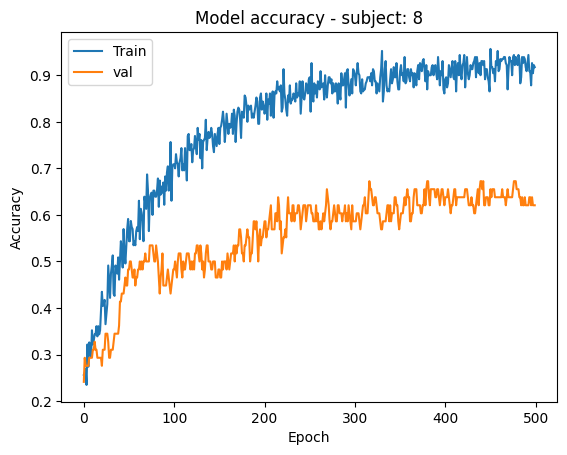

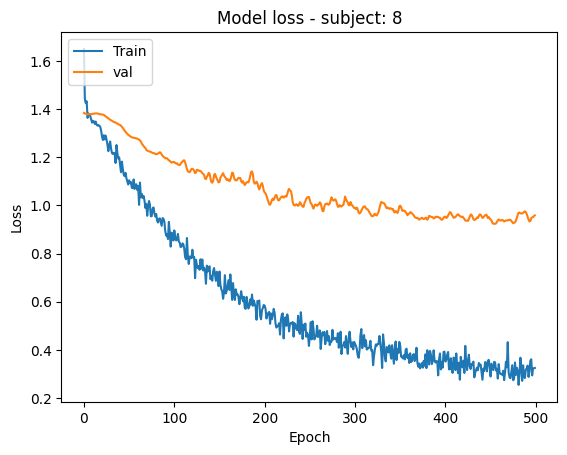


Training on subject  9


Before preprocessing X_train shape is:(230, 1, 22, 1125)
Before preprocessing X_val shape is:(58, 1, 22, 1125)


After preprocessing X_train shape is:(230, 1, 22, 1126)
After preprocessing X_val shape is:(58, 1, 22, 1126)
New X_train shape is: (230, 1, 22, 1125)
New X_val shape is: (58, 1, 22, 1125)
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 461ms/step
Subject: 9   seed 1   time: 1.0 m   valid_acc: 0.7241   valid_loss: 0.746
Plot Learning Curves ....... 


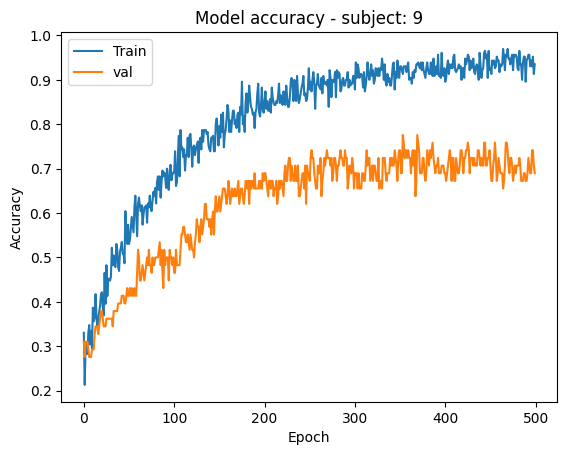

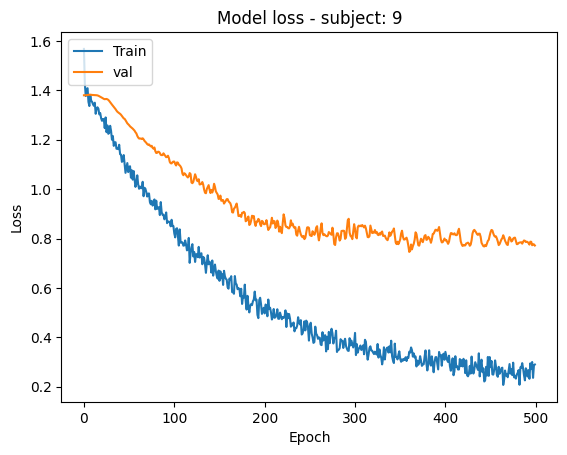


---------------------------------
Validation performance (acc %):
---------------------------------
         sub_1   sub_2   sub_3   sub_4   sub_5   sub_6   sub_7   sub_8   sub_9     average
         -----   -----   -----   -----   -----   -----   -----   -----   -----     -------
Seed 1:  50.00   60.34   65.52   67.24   74.14   58.62   74.14   63.79   72.41     65.13   
---------------------------------
Average acc - all seeds: 65.13 %

Train Time  - all seeds: 9.3 min
---------------------------------

New X_test shape is: (288, 1, 22, 1125)
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  
New X_test shape is: (288, 1, 22, 1125)
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
New X_test shape is: (288, 1, 22, 1125)
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
New X_test shape is: (288, 1, 22, 1125)
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
New X_test shape is: (288, 1, 22, 1125)
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
New X_test shape is: (288, 1, 22, 1125)
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
New X_test shape is:

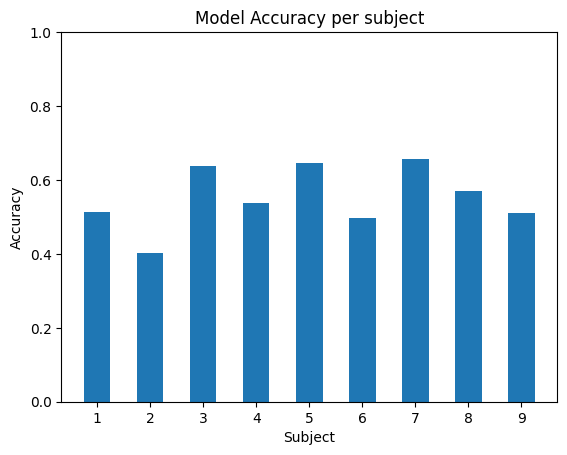

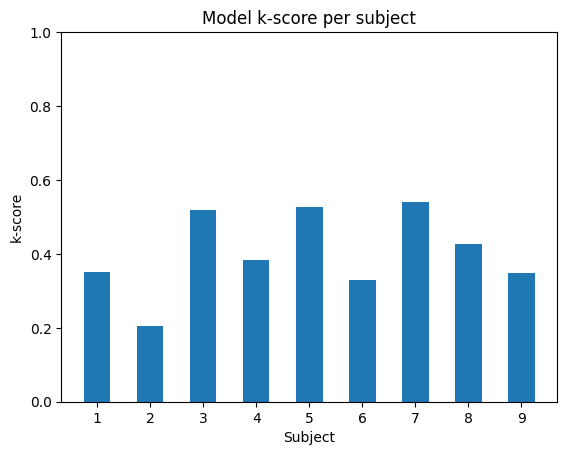

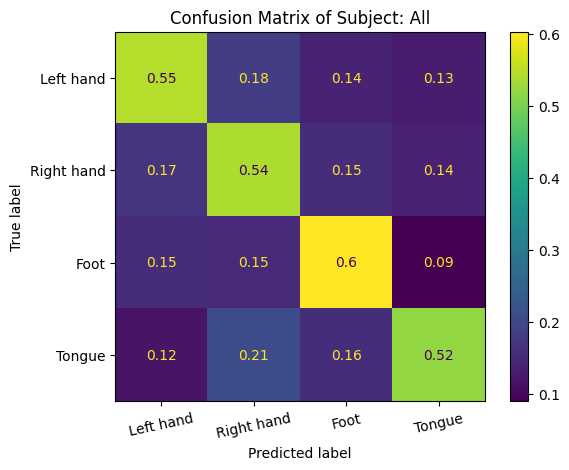

In [27]:
run("db4_hard")